# Reproducing Prospector with tengri

Prospector (Johnson, Leja, Conroy & Speagle 2021) is the most widely
used Bayesian SED-fitting framework in extragalactic astronomy. Its
forward model is FSPS (Conroy, Gunn & White 2009), called through
`python-fsps`, with dust-attenuation curves taken from `sedpy`. This
notebook places that forward model — single stellar populations, the
delayed-τ star formation history *and the non-parametric SFH families
Prospector is known for* (continuity, continuity-flex, Dirichlet, and
post-starburst), the Calzetti / Charlot & Fall /
Kriek & Conroy attenuation laws, the Draine & Li (2007) dust emission,
the Byler (2017) nebular grid, the Nenkova (2008) AGN torus, and the
Madau (1995) IGM — next to its tengri equivalents on the same axes, in
the same units, at matched parameter values.

**What sits on each side.** The left panel of every figure is FSPS
evaluated live through `python-fsps` (the exact engine Prospector holds
in `CSPSpecBasis.ssp` during a fit). The right panel is tengri. Both
read the *same* stellar templates: tengri loads the FSPS MIST + MILES
Chabrier SSP grid from the public catalogue, so a §1 residual below
floating-point precision is interpolation alone, not a different
library. The grid is downloaded at run time, not shipped — see the
README.

The fiducial galaxy through the SED panels: a τ-delayed star formation
history with τ = 1 Gyr observed at 5 Gyr; solar metallicity; a
Calzetti+2000 law at A_V = 1; and Draine & Li (2007) IR re-emission at
(q_PAH, U_min, γ) = (2.5, 1.0, 0.05). Each section sweeps one physics
block around this fiducial.

**What to expect.** The closed-form blocks — the SFH shape, the
attenuation curves, and the IGM — and the shared SSP grid reproduce
FSPS to floating point or a fraction of a percent. The nebular block is
the deliberate exception: FSPS uses the Byler+2017 Cloudy grid baked
into the population synthesis, while tengri uses Cue (Li et al. 2025),
a neural emulator trained on a different Cloudy version. The resulting
Hα ratio is quantified in §8 rather than papered over.

Prospector has no X-ray or radio component, so those sections are
omitted. The CIGALE reproduction notebook covers the panchromatic
X-ray / radio stack.

## Setup

In [1]:
import os

os.environ.setdefault("TENGRI_NO_BACKGROUND_COMPILE", "1")
# python-fsps needs SPS_HOME to find the FSPS tables; the driver also
# checks this and raises a friendly error if it is unset.
if not os.environ.get("SPS_HOME"):
    raise SystemExit(
        "SPS_HOME is not set. Point it at your FSPS checkout before running:\n"
        "    export SPS_HOME=/path/to/fsps\n"
        "See reproduction/prospector/README.md."
    )

import warnings
from pathlib import Path

import jax
import matplotlib.pyplot as plt
import numpy as np
from reproduction.prospector._drivers import prospector_driver as P, units as U

import tengri
from tengri import FIXED, Fixed, SEDModel, load_ssp_data

# Force the inline backend so figures embed on (re-)render regardless of the
# ambient MPLBACKEND. A non-inline backend (e.g. Agg) drops the save_fig()
# auto-display and produces a figure-less notebook. No-op when run as a script.
try:  # noqa: SIM105
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass

warnings.filterwarnings("ignore")
tengri.plot.setup_style()

# Unit-sanity guard: FSPS returns L_ν in L⊙/Hz, which the driver scales
# by FSPS' own L⊙ to reach erg/s/Hz. Every panel below claims
# percent-level agreement, so a factor bug in the converter would
# silently misshape the whole notebook. Assert the bolometric round-trip
# here — the notebook trips at Setup if the converter ever drifts.
_unit_check = U.verify_unit_conversion(rtol=1e-3)
print(
    f"unit-conversion bolometric round-trip: "
    f"rel_err = {_unit_check['rel_err']:.2e}  (target < 1e-3)"
)

# Metallicity pin. FSPS `logzsol` and tengri `logzsol` are both
# log10(Z / Z⊙); the FSPS MILES grid uses Z⊙ = 10**(-1.848) (Asplund+2009).
# Solar on both sides is logzsol = 0.
LOG10_ZSUN = -1.848
MET_LOGZSOL = 0.0
STELLAR_FIDUCIAL = {"logzsol": Fixed(MET_LOGZSOL), "*": FIXED}

# Fiducial galaxy shared across the SED panels.
LOG_MASS_FIDUCIAL = 10.0
TAU_GYR_FIDUCIAL = 1.0
AGE_GYR_FIDUCIAL = 5.0
AV_FIDUCIAL = 1.0
QPAH_FIDUCIAL = 2.5
UMIN_FIDUCIAL = 1.0
GAMMA_FIDUCIAL = 0.05
# FSPS spectra are per 1 M⊙ formed; tengri's log_total_mass sets an
# absolute formed mass. To compare absolute L_ν the FSPS side is scaled
# by MASS_SCALE so both panels show a 10^10 M⊙ galaxy.
MASS_SCALE = 10.0**LOG_MASS_FIDUCIAL

# nbclient kernels don't bind ``__file__`` (the kernel's resources path
# is the notebook directory instead), so fall back to the CWD.
_HERE = Path(__file__).resolve().parent if "__file__" in dir() else Path.cwd().resolve()
figs_dir = _HERE / "_figs"
figs_dir.mkdir(exist_ok=True)

_FIG_DPI = 150


def save_fig(filename: str) -> None:
    """Save figure to ``_figs/`` and leave it open so inline embeds work."""
    plt.savefig(str(figs_dir / filename), dpi=_FIG_DPI, bbox_inches="tight")


def _assert_comparable(arr_ref, arr_t, *, name: str) -> None:
    """Guard against shipping a blank or wildly mis-scaled panel."""
    a_ref = np.asarray(arr_ref)
    a_t = np.asarray(arr_t)
    assert np.isfinite(a_ref).any() and np.isfinite(a_t).any(), f"{name}: NaN-only"
    assert (a_ref > 0).any() and (a_t > 0).any(), f"{name}: zero/negative-only"
    ratio = a_ref.max() / a_t.max()
    assert 1e-3 < ratio < 1e3, f"{name}: y-scale ratio {ratio:.2e} out of range"

W0619 14:03:10.341221 40419232 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


unit-conversion bolometric round-trip: rel_err = 3.11e-06  (target < 1e-3)


## Common SSP grid

tengri reads the FSPS MIST isochrones + MILES spectral library at a
Chabrier IMF — the same templates the local FSPS install is compiled
with. The grid is fetched once from the public catalogue and cached
under `_drivers/data/`; it is not committed to the repository.

In [2]:
ssp_path = tengri.download_ssp("fsps_mist_miles_chabrier", dest=str(_HERE / "_drivers" / "data"))
ssp = load_ssp_data(str(ssp_path))
print(
    f"FSPS MIST+MILES Chabrier SSP: {ssp.ssp_wave.shape[0]} wavelengths, "
    f"{ssp.ssp_lgmet.shape[0]} metallicities, "
    f"{ssp.ssp_lg_age_gyr.shape[0]} age bins; "
    f"λ up to {ssp.ssp_wave.max():.1e} Å."
)

  0%|          | 0.00/61.6M [00:00<?, ?B/s]

  0%|          | 8.19k/61.6M [00:00<15:21, 66.9kB/s]

  0%|          | 32.8k/61.6M [00:00<08:04, 127kB/s] 

  0%|          | 98.3k/61.6M [00:00<03:49, 268kB/s]

  0%|          | 213k/61.6M [00:00<02:13, 459kB/s] 

...

100%|█████████▉| 61.3M/61.6M [00:56<00:00, 1.26MB/s]

100%|█████████▉| 61.5M/61.6M [00:56<00:00, 1.24MB/s]

100%|██████████| 61.6M/61.6M [00:56<00:00, 1.09MB/s]

Downloaded SSP to /private/tmp/wt-parity/reproduction/prospector/_drivers/data/fsps_mist_miles_chabrier.h5
FSPS MIST+MILES Chabrier SSP: 5994 wavelengths, 12 metallicities, 107 age bins; λ up to 1.0e+08 Å.



W0619 14:04:11.589331 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:04:11.602464 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:04:11.607527 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


## §1 Single stellar populations

FSPS MIST + MILES at solar metallicity, from 1 Myr to 10 Gyr. **Single
SSPs**, overlaid: FSPS evaluated live with `get_spectrum` (solid)
against the same templates re-shaped into tengri's HDF5 (black dashed).
The lower panel shows the relative residual
`|tengri − FSPS| / FSPS`. Both sides read identical numerics, so the
residual floor is the float32 round-trip through the grid port — the
grey line marks 1e-6.

W0619 14:04:11.694118 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:04:11.698233 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0619 14:04:11.702090 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


§1 SSP 1 Gyr optical residual: median 1.80e-09, max 3.74e-08


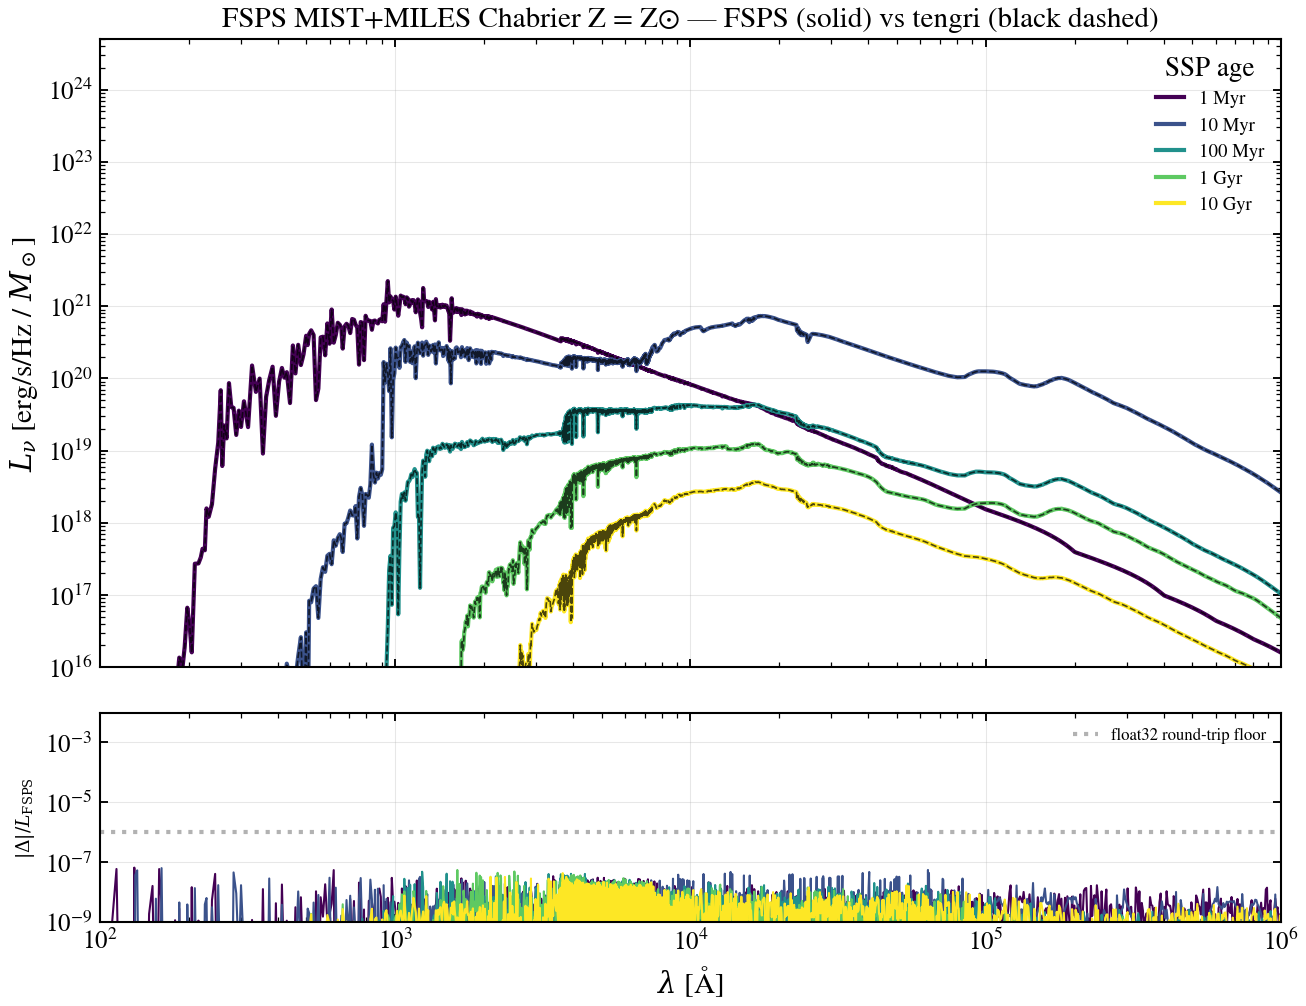

In [3]:
_target_ages_yr = [1e6, 1e7, 1e8, 1e9, 1e10]
i_zsun = int(np.argmin(np.abs(ssp.ssp_lgmet - LOG10_ZSUN)))
# Use grid-native ages so FSPS and the ported grid land on the same age
# samples (no age interpolation on either side).
_age_idx = [
    int(np.argmin(np.abs(ssp.ssp_lg_age_gyr - np.log10(a / 1e9)))) for a in _target_ages_yr
]

fps_ssp, tng_ssp, age_labels = [], [], []
for ia in _age_idx:
    age_gyr = float(10.0 ** ssp.ssp_lg_age_gyr[ia])
    w_p, L_p = P.ssp_spectrum(logzsol=0.0, age_gyr=age_gyr)
    fps_ssp.append((w_p, L_p))
    tng_ssp.append((ssp.ssp_wave, np.asarray(ssp.ssp_flux[i_zsun, ia, :]) * U.L_SUN_ERG_PER_S))
    age_labels.append(f"{age_gyr * 1e3:g} Myr" if age_gyr < 1 else f"{age_gyr:g} Gyr")

fig, (ax, ax_r) = plt.subplots(
    2, 1, figsize=(9, 7), sharex=True, gridspec_kw={"height_ratios": [3, 1]}
)
colors = plt.cm.viridis(np.linspace(0, 1, len(_age_idx)))
for color, label, (w_p, L_p), (w_t, L_t) in zip(colors, age_labels, fps_ssp, tng_ssp):
    ax.plot(w_p, L_p, color=color, linewidth=2.0, label=label)
    ax.plot(w_t, L_t, color="k", linewidth=0.8, linestyle="--", alpha=0.7)
    L_t_on_p = U.regrid(w_t, L_t, w_p)
    resid = np.abs(L_t_on_p - L_p) / np.maximum(np.abs(L_p), 1e-30)
    resid[~np.isfinite(resid)] = 0.0
    ax_r.plot(w_p, resid, color=color, linewidth=1.0)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(1e2, 1e6)
ax.set_ylim(1e16, 5e24)
ax.set_ylabel(r"$L_\nu$ [erg/s/Hz / $M_\odot$]")
ax.set_title("FSPS MIST+MILES Chabrier Z = Z⊙ — FSPS (solid) vs tengri (black dashed)")
ax.legend(fontsize=9, title="SSP age")
ax.grid(True, alpha=0.3)
ax_r.set_xscale("log")
ax_r.set_yscale("log")
ax_r.set_xlabel(r"$\lambda$ [Å]")
ax_r.set_ylabel(r"$|\Delta| / L_{\rm FSPS}$", fontsize=9)
ax_r.set_ylim(1e-9, 1e-2)
ax_r.axhline(1e-6, color="grey", linestyle=":", alpha=0.6, label="float32 round-trip floor")
ax_r.legend(loc="upper right", fontsize=8)
ax_r.grid(True, alpha=0.3)
fig.tight_layout()
save_fig("prospector_01_ssp_fsps.png")

# Median residual in the optical, a useful scalar for the docs page.
_w_ref, _L_ref = fps_ssp[3]  # 1 Gyr
_mask = (_w_ref >= 3000) & (_w_ref <= 10000)
_t_on_p = U.regrid(tng_ssp[3][0], tng_ssp[3][1], _w_ref)
_res = np.abs(_t_on_p[_mask] - _L_ref[_mask]) / np.maximum(_L_ref[_mask], 1e-30)
print(f"§1 SSP 1 Gyr optical residual: median {np.median(_res):.2e}, max {_res.max():.2e}")

## §2 Star formation history — delayed-τ

FSPS `sfh=4` (Prospector's `parametric_sfh` template) uses the
delayed-exponential `SFR(t) ∝ t · exp(−t/τ)`, peaking at `t = τ`.
tengri's `sfh.delayed` is the same closed form. Both normalise to the
same formed mass: FSPS via `mass`, tengri via `log_total_mass`.

**What the right panel plots.** Not a fine-grid analytic curve — that
would compare two formulas, not test tengri. It reads
`state.derived["sfr_history"]` off a built `SEDModel`, on the
log-spaced lookback grid the SFH-convolution code actually uses. The
printed `∫SFR dt` confirms the area integrates to 1 M⊙ formed (tengri
`log_total_mass = 0`).

W0619 14:04:48.930903 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:04:48.934650 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:04:48.938200 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:04:48.941902 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:04:48.945320 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:04:48.948755 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:04:48.952694 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:04:48.965220 40419070 pjrt_executable.cc:638] 

W0619 14:04:49.135861 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:04:49.142473 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:04:49.200163 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:04:49.209099 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:04:49.213036 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:04:49.216996 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:04:49.221108 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:04:49.224918 40419070 pjrt_executable.cc:638] 

W0619 14:04:49.356744 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:04:49.367458 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:04:49.396755 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:04:49.400896 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:04:49.499047 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:04:49.514536 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:04:49.519898 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:04:49.523867 40419070 pjrt_executable.cc:638] 

W0619 14:04:49.561314 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:04:49.565502 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:04:49.581932 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:04:49.588577 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:04:49.597389 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:04:49.601269 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:04:49.604997 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:04:49.608897 40419070 pjrt_executable.cc:638] 

W0619 14:04:49.763269 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:04:49.790538 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:04:49.818175 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:04:49.878160 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:04:49.882909 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:04:49.887865 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:04:49.893642 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:04:49.898365 40419070 pjrt_executable.cc:638] 

W0619 14:04:49.967297 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:04:49.972035 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:04:49.976692 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:04:49.982013 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:04:49.986495 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:04:49.991558 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:04:49.995662 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:04:50.000028 40419070 pjrt_executable.cc:638] 

§2 ∫SFR dt: FSPS = 1.0000 M⊙, tengri pipeline = 1.0000 M⊙ (target 1.0000)


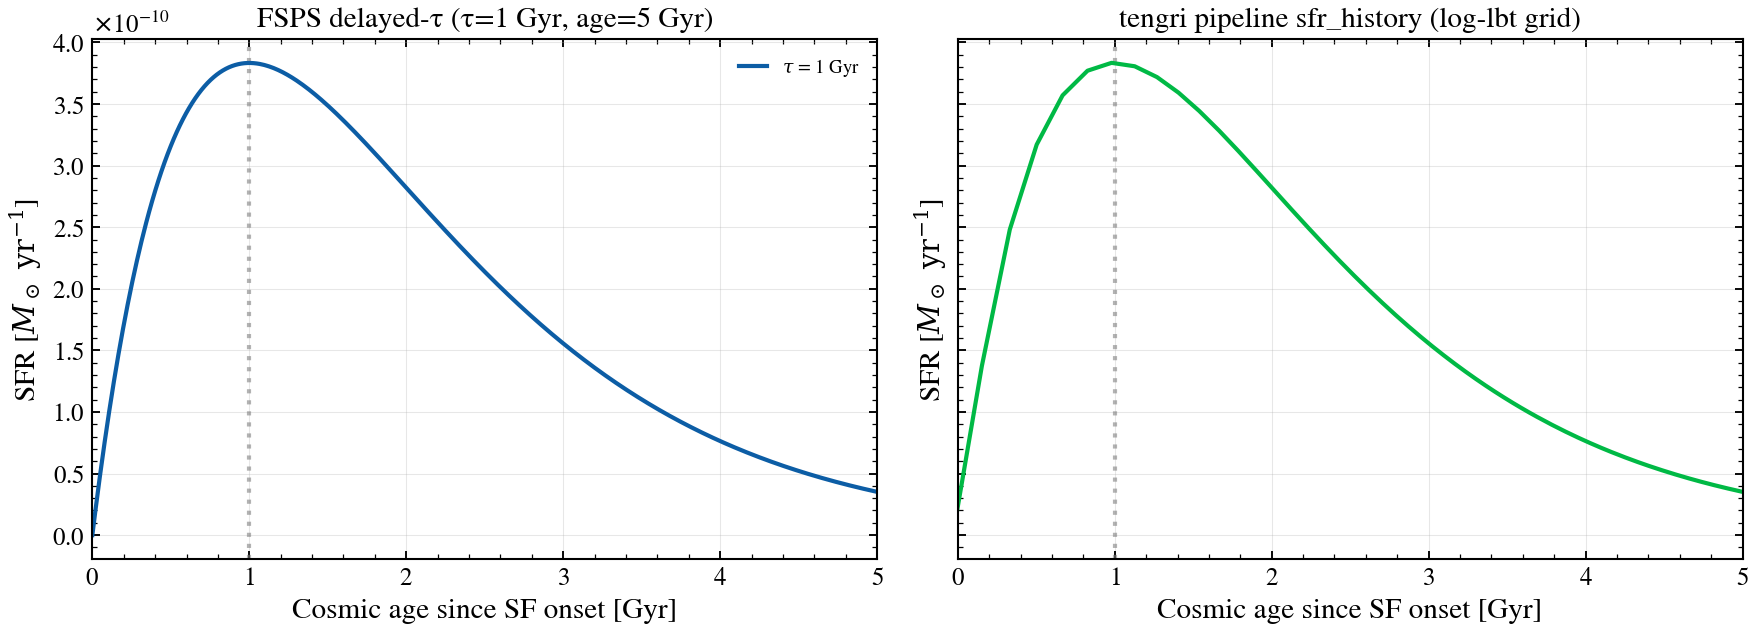

In [4]:
t_p, sfr_p = P.sfh_curve(tau=TAU_GYR_FIDUCIAL, tage=AGE_GYR_FIDUCIAL)
t_p_cosmic_gyr = AGE_GYR_FIDUCIAL - t_p / 1e9
_mass_p = float(np.trapezoid(sfr_p[np.argsort(t_p)], t_p[np.argsort(t_p)]))

_m_sfh = SEDModel.build(
    ssp_data=ssp,
    stellar=STELLAR_FIDUCIAL,
    sfh={
        "type": "delayed",
        "tau_gyr": Fixed(TAU_GYR_FIDUCIAL),
        "age_gyr": Fixed(AGE_GYR_FIDUCIAL),
        "log_total_mass": Fixed(0.0),
        "*": FIXED,
    },
    dust={"type": "two_component", "tau_bc": Fixed(0.0), "tau_diff": Fixed(0.0), "*": FIXED},
    redshift=Fixed(0.0),
)
_state_sfh = _m_sfh.predict_state({})
_lbt_yr = np.asarray(_state_sfh.derived["sfh_grid_lbt_yr"])
_sfr_history = np.asarray(_state_sfh.derived["sfr_history"])
t_t_cosmic_gyr = AGE_GYR_FIDUCIAL - _lbt_yr / 1e9
_idx = np.argsort(_lbt_yr)
_mass_t = float(np.trapezoid(_sfr_history[_idx], _lbt_yr[_idx]))
print(f"§2 ∫SFR dt: FSPS = {_mass_p:.4f} M⊙, tengri pipeline = {_mass_t:.4f} M⊙ (target 1.0000)")

fig, ax_l, ax_r = U.two_panel_fig()
for ax, title in (
    (ax_l, "FSPS delayed-τ (τ=1 Gyr, age=5 Gyr)"),
    (ax_r, "tengri pipeline sfr_history (log-lbt grid)"),
):
    ax.set_xlabel("Cosmic age since SF onset [Gyr]")
    ax.set_ylabel(r"SFR [$M_\odot\ \mathrm{yr}^{-1}$]")
    ax.set_xlim(0, 5)
    ax.set_yscale("linear")
    ax.set_xscale("linear")
    ax.grid(True, alpha=0.3)
    ax.set_title(title)
    ax.axvline(TAU_GYR_FIDUCIAL, color="grey", linestyle=":", alpha=0.6)
ax_l.plot(t_p_cosmic_gyr, sfr_p, "C0-", linewidth=2.0, label=rf"$\tau$ = {TAU_GYR_FIDUCIAL:g} Gyr")
ax_l.legend(fontsize=9)
ax_r.plot(t_t_cosmic_gyr, _sfr_history, "C1-", linewidth=2.0)
fig.tight_layout()
save_fig("prospector_02_sfh_delayed.png")

## §2′ Non-parametric star formation histories

The delayed-τ form above is the *parametric* SFH. Prospector's defining
capability is its family of **non-parametric** histories: piecewise-constant
SFR in lookback-time bins, with the bin amplitudes (or mass fractions) free.
Prospector builds these in `prospect.models.transforms` — log-SFR ratios or
Dirichlet z-fractions → per-bin stellar masses — and feeds the resulting
step function to FSPS as a *tabular* SFH (`sfh=3`). tengri implements the
same families as analytic step-function SFHs convolved with the SSPs.

Each panel below fixes the same 10^10 M⊙, solar-metallicity, dust-free
galaxy and sweeps the SFH prescription. The left axis overlays the SFR
history both codes evaluate; the right axis overlays the resulting stellar
`L_ν`, with the optical median residual annotated. The seven-bin lookback
grid is shared, so the binning is identical on both sides:

`[0, 0.03, 0.1, 0.3, 1, 3, 6, 13.7] Gyr`.

**Convention.** Prospector orders log-SFR ratios from the most recent bin in
lookback time; `ratios[j] = log10(SFR_j / SFR_{j+1})`. tengri's `ratio_i`
uses the same sign and the same youngest-first ordering, so the *same*
numbers drive both codes — the comparison is at matched parameters, not just
a matched shape.

In [5]:
# Shared seven-bin lookback grid (tengri's DEFAULT_BIN_EDGES_GYR). Passed
# explicitly to both sides so FSPS and tengri bin the history identically.
NONPARAM_EDGES_GYR = np.array([0.0, 0.03, 0.1, 0.3, 1.0, 3.0, 6.0, 13.7])
AGE_UNIV_GYR = float(NONPARAM_EDGES_GYR[-1])  # observation epoch (z = 0)


def _step_sfr(agebins, masses):
    """Step-function SFR [M⊙/yr] per bin and the cosmic-age edges for plotting."""
    edges_yr = np.concatenate([10.0 ** agebins[:, 0], [10.0 ** agebins[-1, 1]]])
    sfr_bins = np.asarray(masses) / np.diff(edges_yr)
    cosmic_edges = AGE_UNIV_GYR - edges_yr / 1e9  # lookback → cosmic age [Gyr]
    return sfr_bins, cosmic_edges


def _plot_step(ax, agebins, masses, color, label):
    """Draw a piecewise-constant SFR(cosmic age) from (agebins, masses)."""
    sfr_bins, cosmic_edges = _step_sfr(agebins, masses)
    for i in range(sfr_bins.shape[0]):
        ax.plot(
            [cosmic_edges[i + 1], cosmic_edges[i]],
            [sfr_bins[i], sfr_bins[i]],
            color=color,
            linewidth=2.0,
            label=label if i == 0 else None,
        )


def _tengri_nonparam(sfh_dict, params=None):
    """Build a dust-free tengri model from an SFH dict and return its state."""
    model = SEDModel.build(
        ssp_data=ssp,
        stellar=STELLAR_FIDUCIAL,
        sfh=sfh_dict,
        dust={"type": "two_component", "tau_bc": Fixed(0.0), "tau_diff": Fixed(0.0), "*": FIXED},
        redshift=Fixed(0.0),
    )
    return model, model.predict_state(params if params is not None else {})


def _optical_resid(w_ref, L_ref, w_t, L_t):
    """Median |Δ|/L over 3000–10000 Å, after regridding tengri onto FSPS."""
    L_t_on = U.regrid(np.asarray(w_t), np.asarray(L_t), np.asarray(w_ref))
    m = (w_ref >= 3000) & (w_ref <= 10000) & (L_ref > 0)
    return float(np.median(np.abs(L_t_on[m] - L_ref[m]) / L_ref[m]))


def _sfr_sed_fig(title_sfr):
    """Two-panel figure: SFR(cosmic age) on the left, stellar L_ν on the right.

    Independent y-axes — unlike ``U.two_panel_fig`` (``sharey=True`` for two
    SED panels) — because SFR [M⊙/yr] and L_ν [erg/s/Hz] occupy entirely
    different ranges and must not share a y-scale.
    """
    fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(12, 4.5))
    ax_l.set_yscale("linear")  # SFH shape reads best on a linear SFR axis
    ax_l.set_xlabel("Cosmic age [Gyr]")
    ax_l.set_ylabel(r"SFR [$M_\odot\ \mathrm{yr}^{-1}$]")
    ax_l.set_xlim(0, AGE_UNIV_GYR)
    # NB: don't pin the y-range before plotting — that freezes the top and
    # disables autoscale, clipping tall bursts. Each section anchors at 0 via
    # _anchor_sfr_axis() after its curves are drawn.
    ax_l.set_title(title_sfr)
    ax_l.grid(True, alpha=0.3)
    ax_r.set_xscale("log")
    ax_r.set_yscale("log")
    ax_r.set_xlim(1e3, 2e4)
    ax_r.set_xlabel(r"$\lambda_{\rm rest}$ [Å]")
    ax_r.set_ylabel(r"$L_\nu$ [erg/s/Hz]")
    ax_r.set_title("Stellar SED")
    ax_r.grid(True, alpha=0.3)
    return fig, ax_l, ax_r


def _anchor_sfr_axis(ax):
    """Anchor the SFR axis at 0 while keeping the autoscaled top (no clipping)."""
    ax.set_ylim(0.0, ax.get_ylim()[1])


def _tighten_sed_axis(ax, *wave_lnu_pairs):
    """Clamp the SED y-range to the data inside the visible 1000–20000 Å window.

    Autoscaling otherwise keys on the full spectrum — including the far-UV and
    far-IR outside the plotted x-window, where L_ν is orders of magnitude lower
    — squashing the optical/NIR SED into a thin strip at the top of the panel.
    """
    lo, hi = ax.get_xlim()
    ymax = 0.0
    for wave, lnu in wave_lnu_pairs:
        w = np.asarray(wave)
        lv = np.asarray(lnu)
        m = (w >= lo) & (w <= hi) & np.isfinite(lv) & (lv > 0)
        if m.any():
            ymax = max(ymax, float(lv[m].max()))
    if ymax > 0:
        ax.set_ylim(ymax / 50.0, ymax * 2.0)

### §2a Continuity (Leja+2019)

The workhorse non-parametric SFH: a Student-t prior on the log-SFR ratios
between adjacent bins enforces a smooth, continuous history while still
admitting bursts. Here a gently rising history — each bin forms slightly
more than the one before it in lookback time. Prospector's
`logsfr_ratios_to_masses` and tengri's `continuity` consume the identical
ratio array.

W0619 14:04:52.601417 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:04:52.605594 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:04:52.610768 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:04:52.614654 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:04:52.618402 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:04:52.623258 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:04:52.627108 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:04:52.631173 40419070 pjrt_executable.cc:638] 

W0619 14:04:52.829305 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:04:52.839559 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:04:52.891711 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0619 14:04:53.584238 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


§2a continuity: optical median residual 1.78e-03


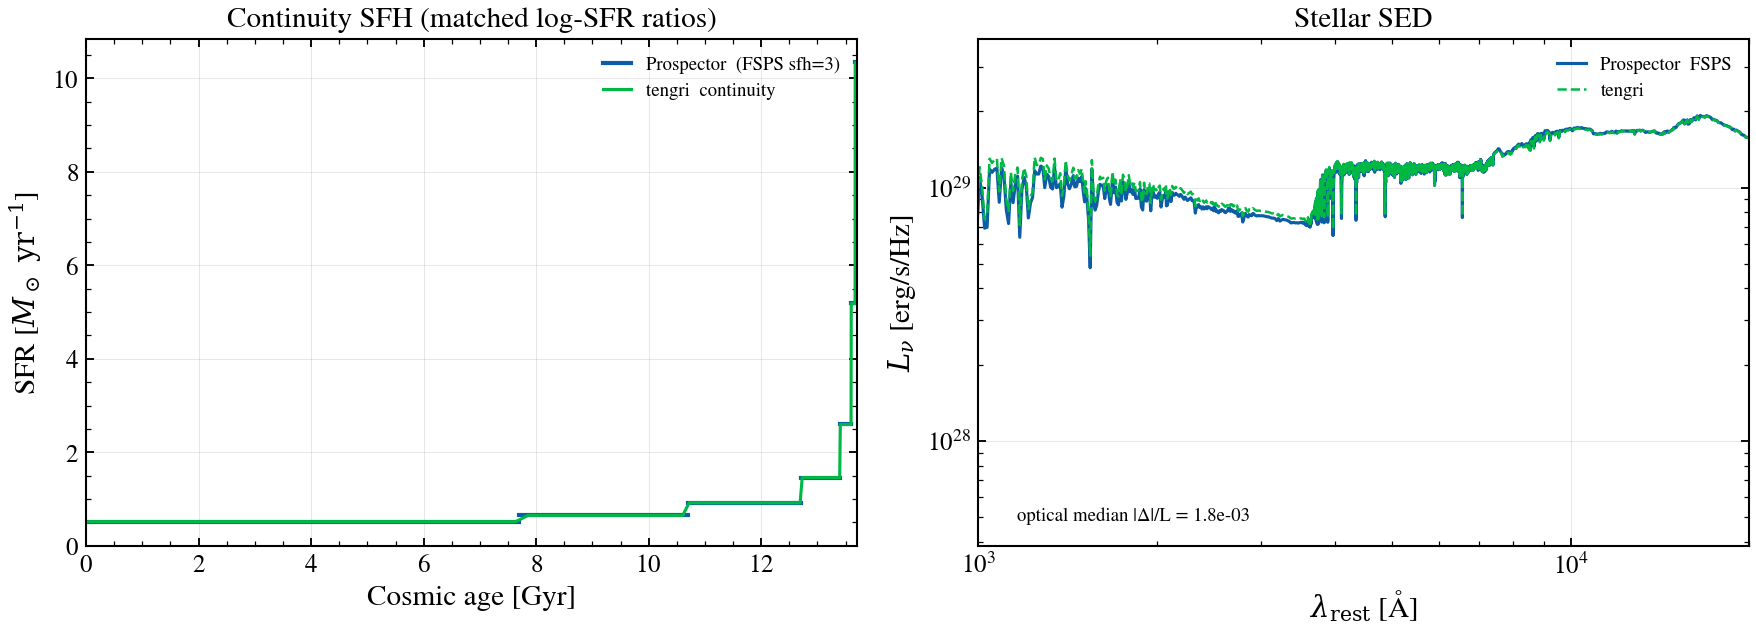

In [6]:
CONT_RATIOS = np.array([0.3, 0.3, 0.25, 0.2, 0.15, 0.1])  # log10(SFR_j / SFR_{j+1})

ab_cont, m_cont = P.continuity_masses(
    bin_edges_gyr=NONPARAM_EDGES_GYR, log_total_mass=LOG_MASS_FIDUCIAL, logsfr_ratios=CONT_RATIOS
)
w_cont, L_cont = P.csp_lnu_binned(agebins=ab_cont, masses=m_cont, logzsol=MET_LOGZSOL)

_sfh_cont = {"type": "continuity", "log_total_mass": Fixed(LOG_MASS_FIDUCIAL), "*": FIXED}
_sfh_cont.update({f"ratio_{i}": Fixed(float(r)) for i, r in enumerate(CONT_RATIOS)})
_m_cont, _s_cont = _tengri_nonparam(_sfh_cont)
_assert_comparable(L_cont, _s_cont.sed_intrinsic, name="§2a continuity")

_lbt_c = np.asarray(_s_cont.derived["sfh_grid_lbt_yr"]) / 1e9
_sfr_c = np.asarray(_s_cont.derived["sfr_history"])
_res_c = _optical_resid(w_cont, L_cont, _s_cont.wave, _s_cont.sed_intrinsic)
print(f"§2a continuity: optical median residual {_res_c:.2e}")

fig, ax_l, ax_r = _sfr_sed_fig("Continuity SFH (matched log-SFR ratios)")
_plot_step(ax_l, ab_cont, m_cont, "C0", "Prospector  (FSPS sfh=3)")
ax_l.plot(AGE_UNIV_GYR - _lbt_c, _sfr_c, "C1-", linewidth=1.5, label="tengri  continuity")
ax_l.legend(fontsize=9)
ax_r.plot(w_cont, L_cont, "C0-", linewidth=1.5, label="Prospector  FSPS")
ax_r.plot(_s_cont.wave, _s_cont.sed_intrinsic, "C1--", linewidth=1.2, label="tengri")
ax_r.text(0.05, 0.05, f"optical median |Δ|/L = {_res_c:.1e}", transform=ax_r.transAxes, fontsize=9)
ax_r.legend(fontsize=9, loc="upper right")
fig.tight_layout()
_anchor_sfr_axis(ax_l)
_tighten_sed_axis(ax_r, (w_cont, L_cont), (_s_cont.wave, _s_cont.sed_intrinsic))
save_fig("prospector_02a_sfh_continuity.png")

### §2b Continuity-flex (Leja+2019)

Continuity with *flexible* bin edges: the inner bin widths are themselves
derived from the log-SFR ratios under a constant-mass-per-flex-bin
constraint, with the youngest and oldest bins anchored. Prospector's
`logsfr_ratios_to_masses_flex` derives the bins; tengri's `continuity_flex`
reproduces the same Leja+2019 construction. Anchors
`[0.0316, 5.012, 13.7] Gyr`, three flex bins.

W0619 14:04:54.265879 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:04:54.272794 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:04:54.277050 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:04:54.309112 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:04:54.313130 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:04:54.316737 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:04:54.320285 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:04:54.323730 40419070 pjrt_executable.cc:638] 

§2b continuity_flex: optical median residual 1.95e-02


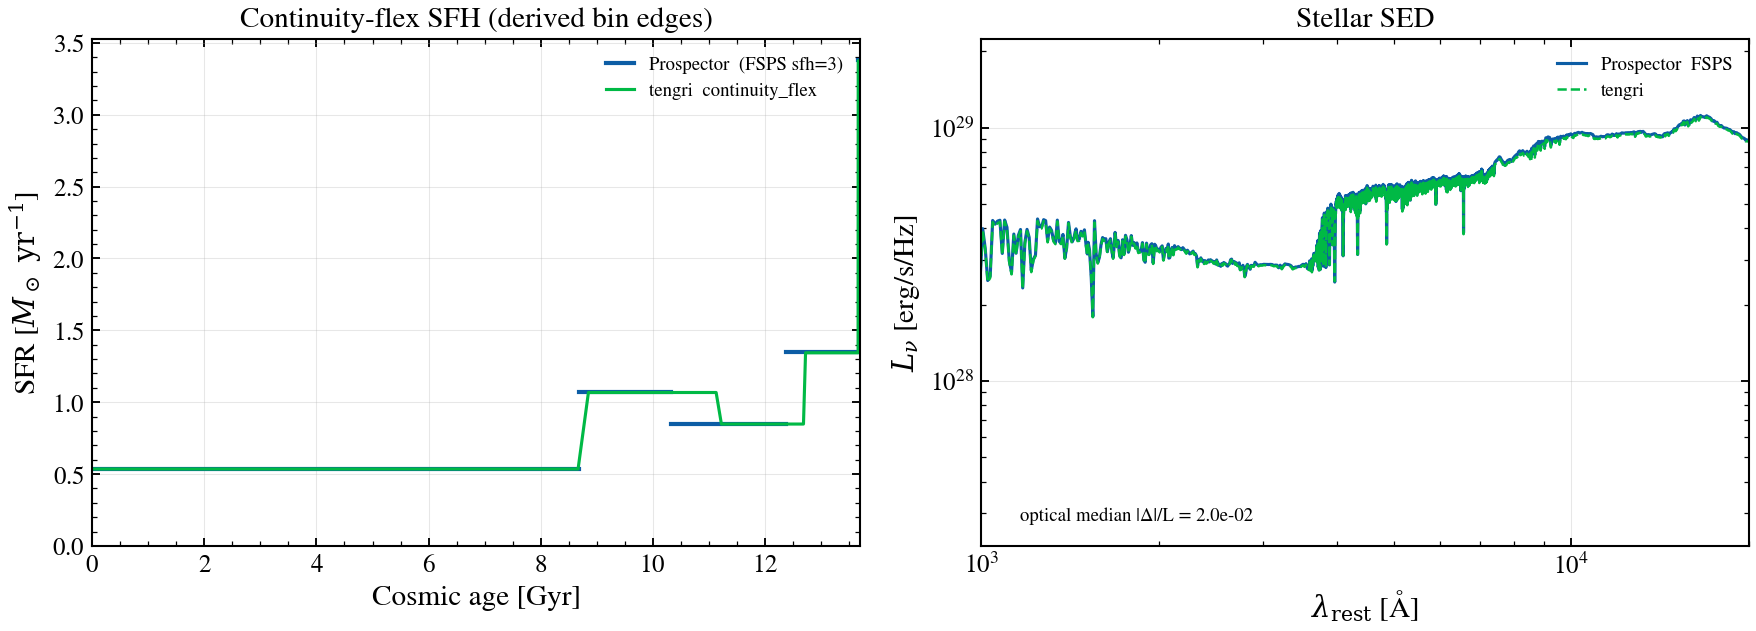

In [7]:
FLEX_ANCHORS_GYR = np.array([0.0316, 5.012, 13.7])
FLEX_RATIO_YOUNG = 0.4
FLEX_INNER = np.array([0.2, -0.1])  # 2 inner ratios → 3 flex bins
FLEX_RATIO_OLD = -0.3

ab_flex, m_flex = P.flex_masses(
    anchor_edges_gyr=FLEX_ANCHORS_GYR,
    log_total_mass=LOG_MASS_FIDUCIAL,
    logsfr_ratio_young=FLEX_RATIO_YOUNG,
    logsfr_ratios=FLEX_INNER,
    logsfr_ratio_old=FLEX_RATIO_OLD,
)
w_flex, L_flex = P.csp_lnu_binned(agebins=ab_flex, masses=m_flex, logzsol=MET_LOGZSOL)

_sfh_flex = {
    "type": "continuity_flex",
    "log_total_mass": Fixed(LOG_MASS_FIDUCIAL),
    "ratio_young": Fixed(FLEX_RATIO_YOUNG),
    "ratio_old": Fixed(FLEX_RATIO_OLD),
    "flex_0": Fixed(float(FLEX_INNER[0])),
    "flex_1": Fixed(float(FLEX_INNER[1])),
    "*": FIXED,
}
_m_flex, _s_flex = _tengri_nonparam(_sfh_flex)
_assert_comparable(L_flex, _s_flex.sed_intrinsic, name="§2b continuity_flex")

_lbt_f = np.asarray(_s_flex.derived["sfh_grid_lbt_yr"]) / 1e9
_sfr_f = np.asarray(_s_flex.derived["sfr_history"])
_res_f = _optical_resid(w_flex, L_flex, _s_flex.wave, _s_flex.sed_intrinsic)
print(f"§2b continuity_flex: optical median residual {_res_f:.2e}")

fig, ax_l, ax_r = _sfr_sed_fig("Continuity-flex SFH (derived bin edges)")
_plot_step(ax_l, ab_flex, m_flex, "C0", "Prospector  (FSPS sfh=3)")
ax_l.plot(AGE_UNIV_GYR - _lbt_f, _sfr_f, "C1-", linewidth=1.5, label="tengri  continuity_flex")
ax_l.legend(fontsize=9)
ax_r.plot(w_flex, L_flex, "C0-", linewidth=1.5, label="Prospector  FSPS")
ax_r.plot(_s_flex.wave, _s_flex.sed_intrinsic, "C1--", linewidth=1.2, label="tengri")
ax_r.text(0.05, 0.05, f"optical median |Δ|/L = {_res_f:.1e}", transform=ax_r.transAxes, fontsize=9)
ax_r.legend(fontsize=9, loc="upper right")
fig.tight_layout()
_anchor_sfr_axis(ax_l)
_tighten_sed_axis(ax_r, (w_flex, L_flex), (_s_flex.wave, _s_flex.sed_intrinsic))
save_fig("prospector_02b_sfh_continuity_flex.png")

### §2c Dirichlet (Leja+2017)

The Dirichlet SFH places a symmetric prior on the fraction of star formation
in each bin. We lead with **Prospector's** parametrisation — the one users
know: latent z-fractions → SFR fractions → bin masses
(`zfrac_to_masses`). tengri implements the same Leja+2017 family but with a
different latent variable (a stick-breaking prior on the *mass* fractions),
so the two codes' z-values are **not** interchangeable. To compare at a
matched, recognisably-Prospector SFH, we draw the history from Prospector's
transform and invert tengri's stick-breaking to the z that reproduces those
same bin masses. Both codes then evaluate the identical step SFH; the SED is
a genuine head-to-head.

W0619 14:04:55.141641 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:04:55.146701 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:04:55.152060 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:04:55.166474 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:04:55.170309 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:04:55.174101 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:04:55.177845 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


§2c dirichlet: optical median residual 1.58e-02


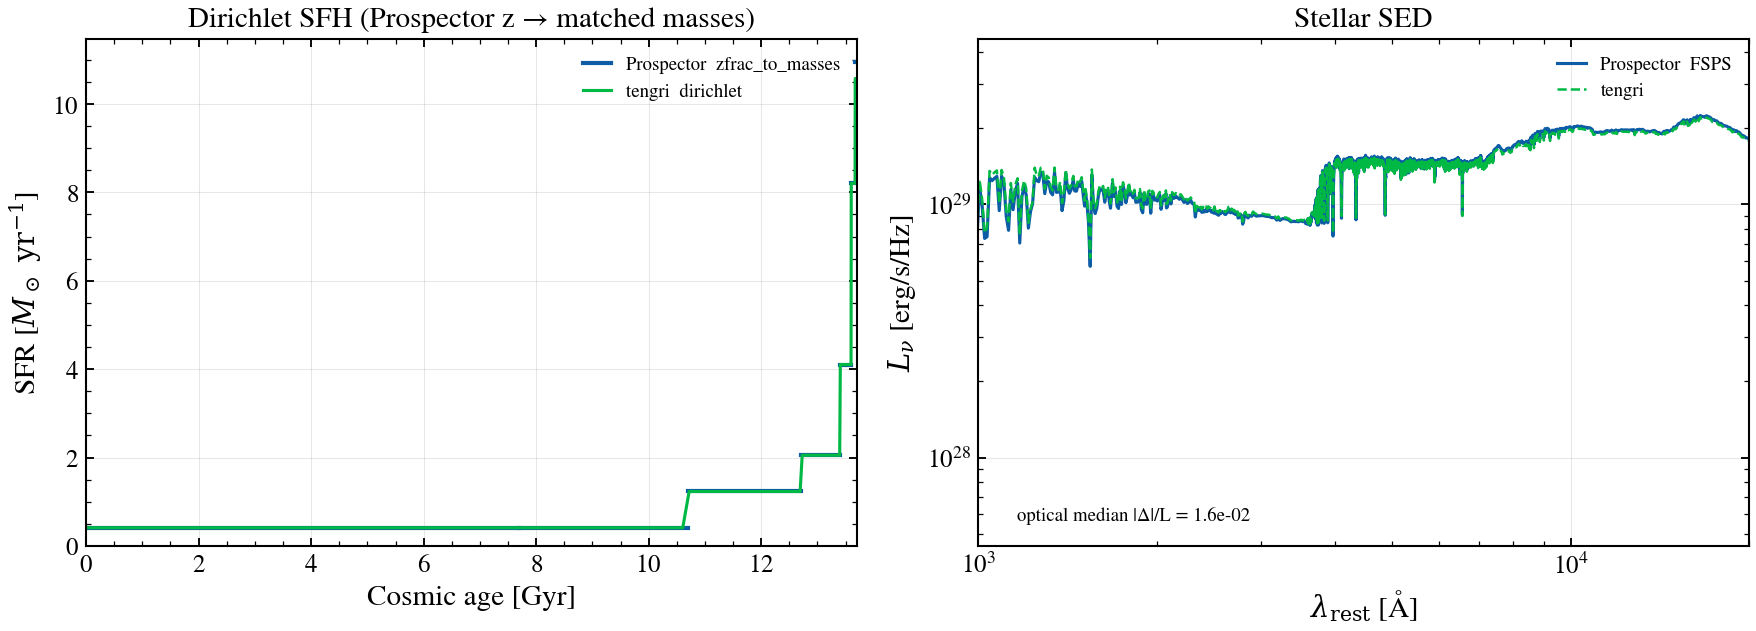

In [8]:
DIR_ZFRAC = np.array([0.6, 0.5, 0.5, 0.5, 0.4, 0.5])  # Prospector latent z-fractions

ab_dir, m_dir = P.dirichlet_masses(
    bin_edges_gyr=NONPARAM_EDGES_GYR, log_total_mass=LOG_MASS_FIDUCIAL, z_fraction=DIR_ZFRAC
)
w_dir, L_dir = P.csp_lnu_binned(agebins=ab_dir, masses=m_dir, logzsol=MET_LOGZSOL)


def _tengri_z_from_massfracs(mass_fracs):
    """Invert tengri's stick-breaking: mass fractions → latent z (youngest first)."""
    z = np.zeros(mass_fracs.shape[0] - 1)
    remaining = 1.0
    for i in range(z.shape[0]):
        z[i] = np.clip(mass_fracs[i] / remaining, 1e-6, 1.0 - 1e-6)
        remaining *= 1.0 - z[i]
    return z


_z_tengri = _tengri_z_from_massfracs(m_dir / m_dir.sum())
_sfh_dir = {"type": "dirichlet", "log_total_mass": Fixed(LOG_MASS_FIDUCIAL), "*": FIXED}
_sfh_dir.update({f"z_{i}": Fixed(float(z)) for i, z in enumerate(_z_tengri)})
_m_dir, _s_dir = _tengri_nonparam(_sfh_dir)
_assert_comparable(L_dir, _s_dir.sed_intrinsic, name="§2c dirichlet")

_lbt_d = np.asarray(_s_dir.derived["sfh_grid_lbt_yr"]) / 1e9
_sfr_d = np.asarray(_s_dir.derived["sfr_history"])
_res_d = _optical_resid(w_dir, L_dir, _s_dir.wave, _s_dir.sed_intrinsic)
print(f"§2c dirichlet: optical median residual {_res_d:.2e}")

fig, ax_l, ax_r = _sfr_sed_fig("Dirichlet SFH (Prospector z → matched masses)")
_plot_step(ax_l, ab_dir, m_dir, "C0", "Prospector  zfrac_to_masses")
ax_l.plot(AGE_UNIV_GYR - _lbt_d, _sfr_d, "C1-", linewidth=1.5, label="tengri  dirichlet")
ax_l.legend(fontsize=9)
ax_r.plot(w_dir, L_dir, "C0-", linewidth=1.5, label="Prospector  FSPS")
ax_r.plot(_s_dir.wave, _s_dir.sed_intrinsic, "C1--", linewidth=1.2, label="tengri")
ax_r.text(0.05, 0.05, f"optical median |Δ|/L = {_res_d:.1e}", transform=ax_r.transAxes, fontsize=9)
ax_r.legend(fontsize=9, loc="upper right")
fig.tight_layout()
_anchor_sfr_axis(ax_l)
_tighten_sed_axis(ax_r, (w_dir, L_dir), (_s_dir.wave, _s_dir.sed_intrinsic))
save_fig("prospector_02c_sfh_dirichlet.png")

### §2d Post-starburst

A post-starburst (PSB) galaxy — a recent burst followed by a sharp quench —
is the regime that motivated Prospector's dedicated PSB template (Suess+2022,
`logsfr_ratios_to_masses_psb`): a young bin `[0, t_last]`, equal-mass flex
bins to `t_flex`, and fixed old bins. tengri implements the same family as
`psb_suess2022` and forward-models it through DSPS.

The cleanest *matched-parameter* head-to-head against FSPS uses the shared
**continuity** basis — a sharp negative youngest log-SFR ratio is a recent
shutdown, and both codes forward-model the continuity SFH exactly. On top of
that comparison (blue/green), the grey dotted curve is tengri's dedicated
`psb_suess2022` template at matched `t_last`/`t_flex`, showing the parametric
PSB shape the family encodes directly.

§2d post-starburst: optical median residual 6.68e-03


W0619 14:04:55.793765 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:04:55.799029 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:04:55.814960 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:04:55.843618 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


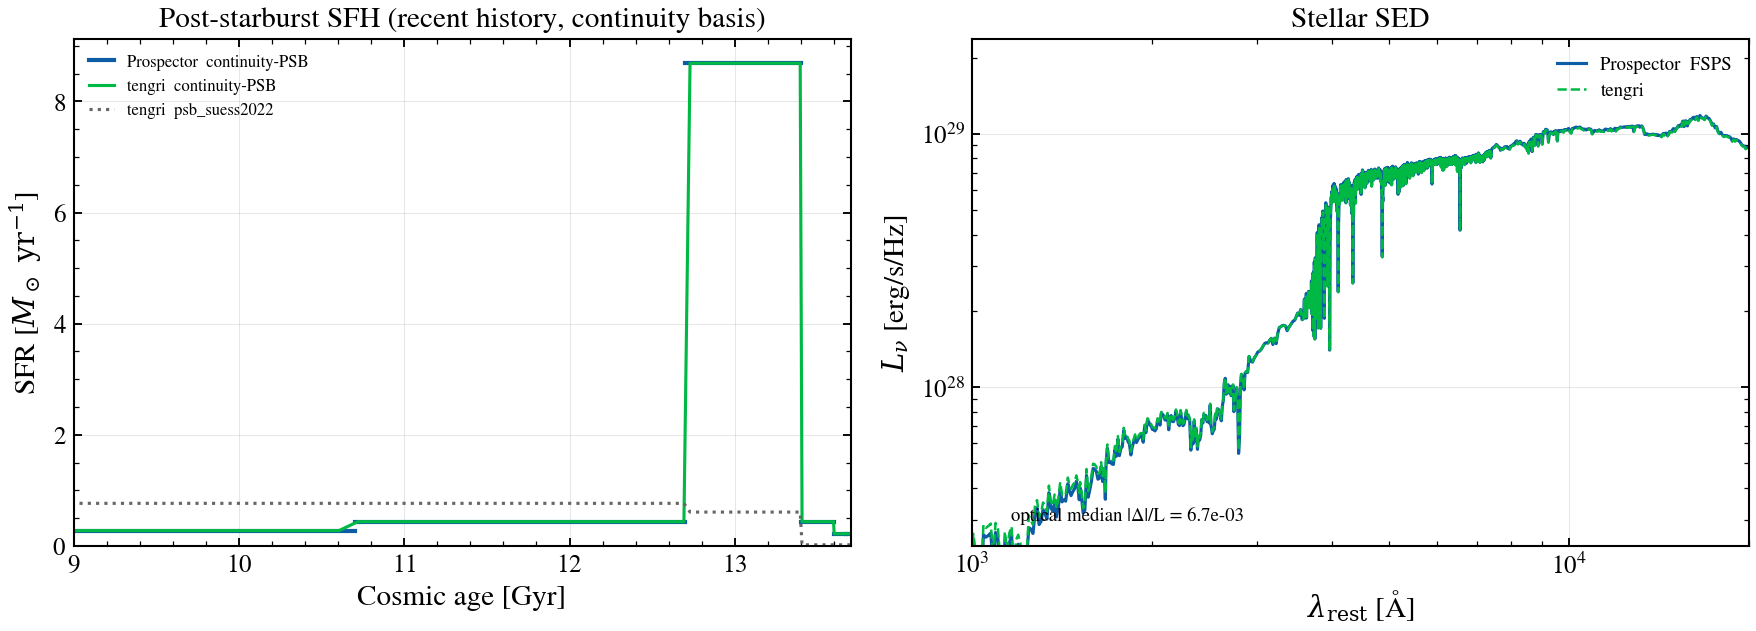

In [9]:
# Post-starburst as continuity ratios: a burst in the 0.3–1 Gyr bin followed by
# a sharp quench in the most recent bins. ratios[j] = log10(SFR_j / SFR_{j+1}),
# j=0 youngest. ratio_2 = -1.3 drops the recent bins well below the burst bin;
# ratio_3 = +1.3 raises the burst bin above the older baseline.
PSB_RATIOS = np.array([0.0, -0.3, -1.3, 1.3, 0.2, 0.0])

ab_psb, m_psb = P.continuity_masses(
    bin_edges_gyr=NONPARAM_EDGES_GYR, log_total_mass=LOG_MASS_FIDUCIAL, logsfr_ratios=PSB_RATIOS
)
w_psb, L_psb = P.csp_lnu_binned(agebins=ab_psb, masses=m_psb, logzsol=MET_LOGZSOL)

_sfh_psb = {"type": "continuity", "log_total_mass": Fixed(LOG_MASS_FIDUCIAL), "*": FIXED}
_sfh_psb.update({f"ratio_{i}": Fixed(float(r)) for i, r in enumerate(PSB_RATIOS)})
_m_psb, _s_psb = _tengri_nonparam(_sfh_psb)
_assert_comparable(L_psb, _s_psb.sed_intrinsic, name="§2d psb")

_lbt_p = np.asarray(_s_psb.derived["sfh_grid_lbt_yr"]) / 1e9
_sfr_p2 = np.asarray(_s_psb.derived["sfr_history"])
_res_p = _optical_resid(w_psb, L_psb, _s_psb.wave, _s_psb.sed_intrinsic)
print(f"§2d post-starburst: optical median residual {_res_p:.2e}")

# tengri's dedicated Suess+2022 PSB template (now wired into the DSPS forward
# pass): youngest bin [0, t_last], one flex bin to t_flex, then fixed old bins.
_sfh_suess = {
    "type": "psb_suess2022",
    "log_total_mass": Fixed(LOG_MASS_FIDUCIAL),
    "tlast_gyr": Fixed(0.3),
    "tflex_gyr": Fixed(2.0),
    "ratio_young": Fixed(-1.5),
    "ratio_old_0": Fixed(0.2),
    "ratio_old_1": Fixed(-0.3),
    "ratio_old_2": Fixed(0.0),
    "*": FIXED,
}
_m_suess, _s_suess = _tengri_nonparam(_sfh_suess)
_lbt_s = np.asarray(_s_suess.derived["sfh_grid_lbt_yr"]) / 1e9
_sfr_s = np.asarray(_s_suess.derived["sfr_history"])

fig, ax_l, ax_r = _sfr_sed_fig("Post-starburst SFH (recent history, continuity basis)")
ax_l.set_xlim(9.0, AGE_UNIV_GYR)  # the PSB signature lives in the last few Gyr
_plot_step(ax_l, ab_psb, m_psb, "C0", "Prospector  continuity-PSB")
ax_l.plot(AGE_UNIV_GYR - _lbt_p, _sfr_p2, "C1-", linewidth=1.5, label="tengri  continuity-PSB")
ax_l.plot(
    AGE_UNIV_GYR - _lbt_s, _sfr_s, ":", color="0.4", linewidth=1.5, label="tengri  psb_suess2022"
)
ax_l.legend(fontsize=8)
ax_r.plot(w_psb, L_psb, "C0-", linewidth=1.5, label="Prospector  FSPS")
ax_r.plot(_s_psb.wave, _s_psb.sed_intrinsic, "C1--", linewidth=1.2, label="tengri")
ax_r.text(0.05, 0.05, f"optical median |Δ|/L = {_res_p:.1e}", transform=ax_r.transAxes, fontsize=9)
ax_r.legend(fontsize=9, loc="upper right")
fig.tight_layout()
_anchor_sfr_axis(ax_l)
_tighten_sed_axis(ax_r, (w_psb, L_psb), (_s_psb.wave, _s_psb.sed_intrinsic))
save_fig("prospector_02d_sfh_psb.png")

### §2e Beyond Prospector — the stochastic IFT field SFH

All four families above bin the SFH and free the bin amplitudes. tengri also
offers a *continuous* stochastic SFH: a smooth backbone (here a delayed
double-power-law) modulated by a Gaussian-process field whose power spectrum
encodes the burstiness timescale (Information-Field-Theory correlated field).
This has no Prospector counterpart — it is not a binned model — and it is the
prior tengri Paper I uses to capture short-timescale fluctuations. Three
independent draws at fixed PSD hyperparameters illustrate the family; the
right panel shows the corresponding stellar SEDs.

W0619 14:04:56.587964 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:04:56.592849 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:04:56.610537 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:04:56.633394 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:04:56.642974 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:04:56.646783 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:04:56.649862 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:04:56.653277 40419070 pjrt_executable.cc:638] 

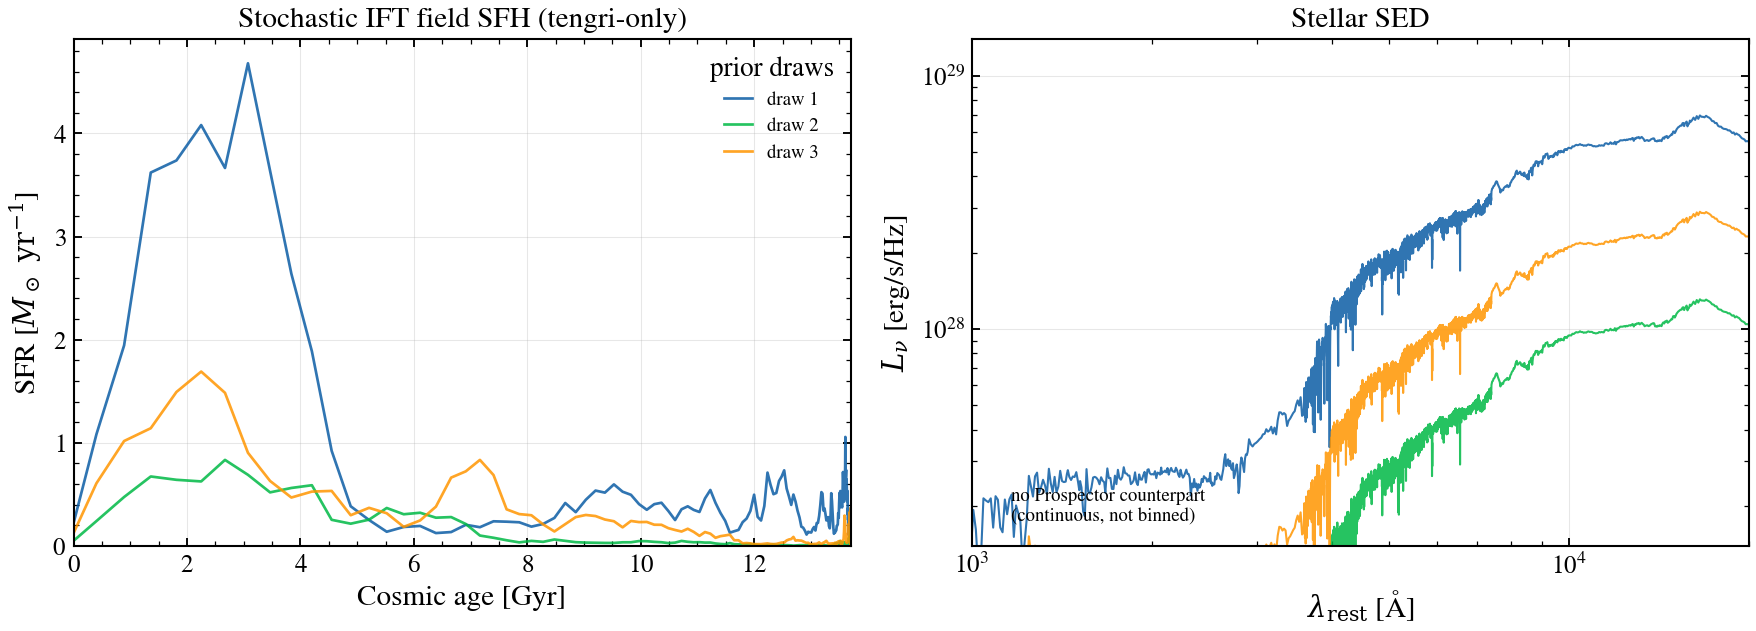

In [10]:
_sfh_field = {
    "type": ["dpl", "field"],
    "log_total_mass": Fixed(LOG_MASS_FIDUCIAL),
    "sfh_dpl_alpha": Fixed(2.0),
    "sfh_dpl_beta": Fixed(1.0),
    "sfh_dpl_tau_gyr": Fixed(3.0),
    "sfh_dpl_age_gyr": Fixed(AGE_UNIV_GYR),
    "sfh_field_psd_sigma": Fixed(2.0),
    "sfh_field_psd_tau_myr": Fixed(150.0),
    "*": FIXED,
}
_m_field = SEDModel.build(
    ssp_data=ssp,
    stellar=STELLAR_FIDUCIAL,
    sfh=_sfh_field,
    dust={"type": "two_component", "tau_bc": Fixed(0.0), "tau_diff": Fixed(0.0), "*": FIXED},
    redshift=Fixed(0.0),
)

fig, ax_l, ax_r = _sfr_sed_fig("Stochastic IFT field SFH (tengri-only)")
_field_seds = []
for k, seed in enumerate([3, 11, 29]):
    _draw = _m_field.spec.sample(jax.random.PRNGKey(seed))
    _sf = _m_field.predict_state(_draw)
    _lbt_ift = np.asarray(_sf.derived["sfh_grid_lbt_yr"]) / 1e9
    ax_l.plot(
        AGE_UNIV_GYR - _lbt_ift,
        np.asarray(_sf.derived["sfr_history"]),
        color=f"C{k}",
        linewidth=1.3,
        alpha=0.85,
        label=f"draw {k + 1}",
    )
    ax_r.plot(_sf.wave, _sf.sed_intrinsic, color=f"C{k}", linewidth=1.0, alpha=0.85)
    _field_seds.append((_sf.wave, _sf.sed_intrinsic))
ax_l.legend(fontsize=9, title="prior draws")
ax_r.text(
    0.05,
    0.05,
    "no Prospector counterpart\n(continuous, not binned)",
    transform=ax_r.transAxes,
    fontsize=9,
)
fig.tight_layout()
_anchor_sfr_axis(ax_l)
_tighten_sed_axis(ax_r, *_field_seds)
save_fig("prospector_02e_sfh_ift_field.png")

## §3 Integrated stellar SED

Convolve the τ-delayed SFH with the MIST+MILES SSPs. No dust, no
nebular. Both panels show `L_ν` vs `λ_rest` for 1 M⊙ formed; the
surviving stellar mass is reported on each side.

§3 stellar SED tengri/FSPS optical (3000–10000 Å): median 1.012, P5 1.011, P95 1.015


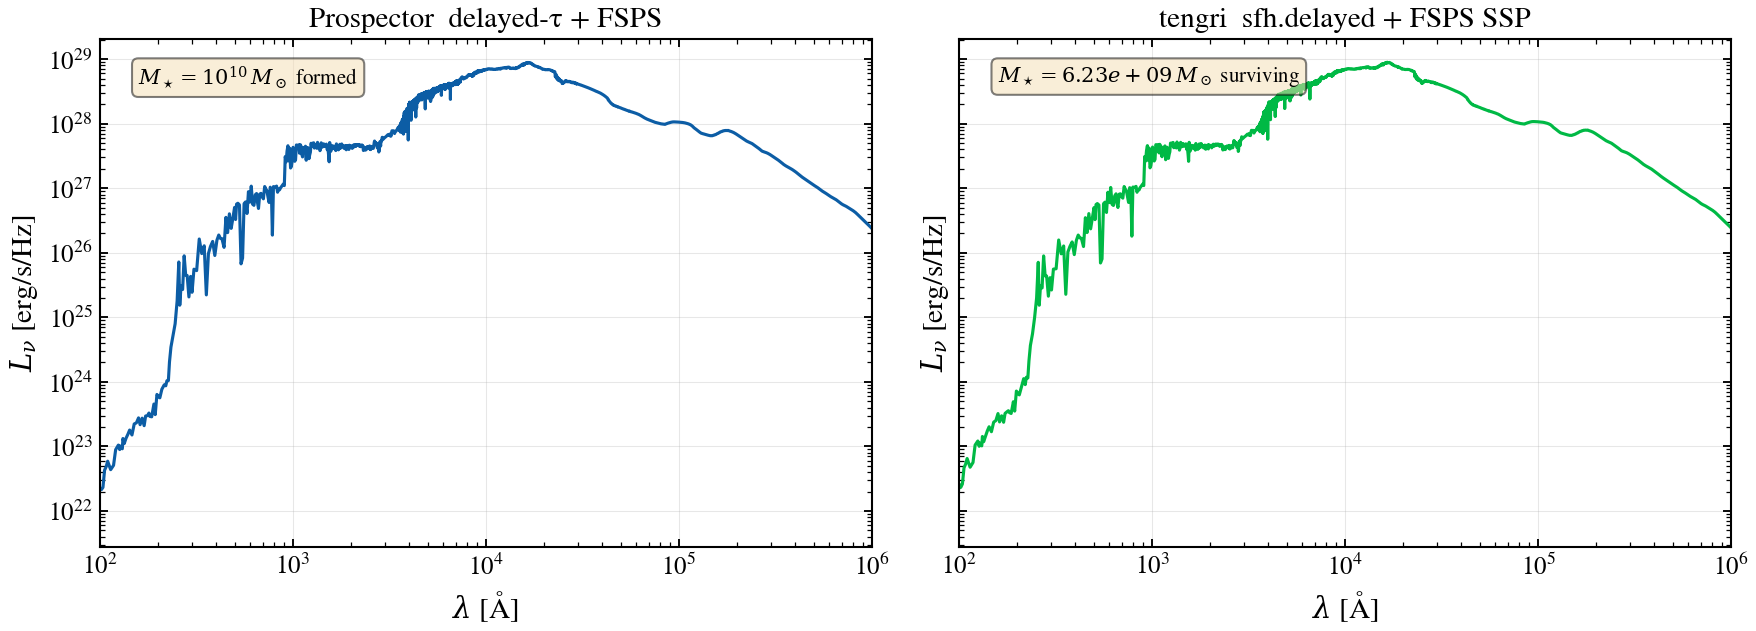

In [11]:
w_p, L_p = P.csp_lnu(logzsol=0.0, tau=TAU_GYR_FIDUCIAL, tage=AGE_GYR_FIDUCIAL, sfh=4, av=0.0)
L_p = L_p * MASS_SCALE  # FSPS is per 1 M⊙ formed → scale to the 10^10 M⊙ galaxy

m_stellar = SEDModel.build(
    ssp_data=ssp,
    stellar=STELLAR_FIDUCIAL,
    sfh={
        "type": "delayed",
        "tau_gyr": Fixed(TAU_GYR_FIDUCIAL),
        "age_gyr": Fixed(AGE_GYR_FIDUCIAL),
        "log_total_mass": Fixed(LOG_MASS_FIDUCIAL),
        "*": FIXED,
    },
    dust={"type": "two_component", "tau_bc": Fixed(0.0), "tau_diff": Fixed(0.0), "*": FIXED},
    redshift=Fixed(0.0),
)
s_stellar = m_stellar.predict_state({})
_assert_comparable(L_p, s_stellar.sed_intrinsic, name="§3 stellar")

fig, ax_l, ax_r = U.two_panel_fig()
U.panel(
    ax_l, ax_r, label_l="Prospector  delayed-τ + FSPS", label_r="tengri  sfh.delayed + FSPS SSP"
)
ax_l.plot(w_p, L_p, "C0-", linewidth=1.5)
ax_l.text(
    0.05,
    0.95,
    rf"$M_\star = 10^{{{LOG_MASS_FIDUCIAL:.0f}}}\,M_\odot$ formed",
    transform=ax_l.transAxes,
    fontsize=10,
    va="top",
    bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5),
)
ax_r.plot(s_stellar.wave, s_stellar.sed_intrinsic, "C1-", linewidth=1.5)
m_star = 10.0 ** float(s_stellar.derived["log_mstar"])
ax_r.text(
    0.05,
    0.95,
    rf"$M_\star = {m_star:.2e}\,M_\odot$ surviving",
    transform=ax_r.transAxes,
    fontsize=10,
    va="top",
    bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5),
)
for ax in (ax_l, ax_r):
    ax.set_xlim(1e2, 1e6)
    ax.grid(True, alpha=0.3)
fig.tight_layout()
save_fig("prospector_03_stellar_sed.png")

_mask_opt = (w_p >= 3000) & (w_p <= 10000)
_t_on_p = U.regrid(np.asarray(s_stellar.wave), np.asarray(s_stellar.sed_intrinsic), w_p)
_ratios = _t_on_p[_mask_opt] / L_p[_mask_opt]
_ratios = _ratios[np.isfinite(_ratios) & (_ratios > 0)]
print(
    f"§3 stellar SED tengri/FSPS optical (3000–10000 Å): "
    f"median {np.median(_ratios):.3f}, P5 {np.percentile(_ratios, 5):.3f}, "
    f"P95 {np.percentile(_ratios, 95):.3f}"
)

## §4 Dust attenuation curves

The three Prospector / FSPS attenuation standards — Calzetti+2000
(`dust_type=2`), Charlot & Fall 2000 (the power-law form,
`dust_type=0`), and Kriek & Conroy 2013 (`dust_type=4`) — shown
against tengri's `calzetti`, `power_law`, and `kriek_conroy` laws.
Both sides evaluate the analytic law directly (tengri via
`tengri.dust.list_laws`), normalised to `A(λ)/A_V` at 5500 Å, so the
comparison is curve against curve with no SSP-convolution noise.

The Kriek & Conroy row is compared against FSPS' own `dust_type=4`
curve — the one Prospector actually applies — rather than `sedpy`'s
`conroy`. (Those are two different KC13 implementations: FSPS ties the
2175 Å bump amplitude to the slope via KC13 Eqn 3 and divides the
Drude by R_V, while `sedpy` scales a Cardelli-relative bump by a fixed
`f_bump = 0.6`.) tengri's `kriek_conroy` reproduces the FSPS
construction, so the bump excess above the local Calzetti baseline
matches; both are printed below.

W0619 14:04:58.432043 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:04:58.437555 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:04:58.441426 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:04:58.445670 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:04:58.450501 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:04:58.453807 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:04:58.457466 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:04:58.461289 40419070 pjrt_executable.cc:638] 

§4 Kriek & Conroy 2175 Å bump (A_λ/A_V above baseline): FSPS dust_type=4 = 0.166, tengri = 0.165


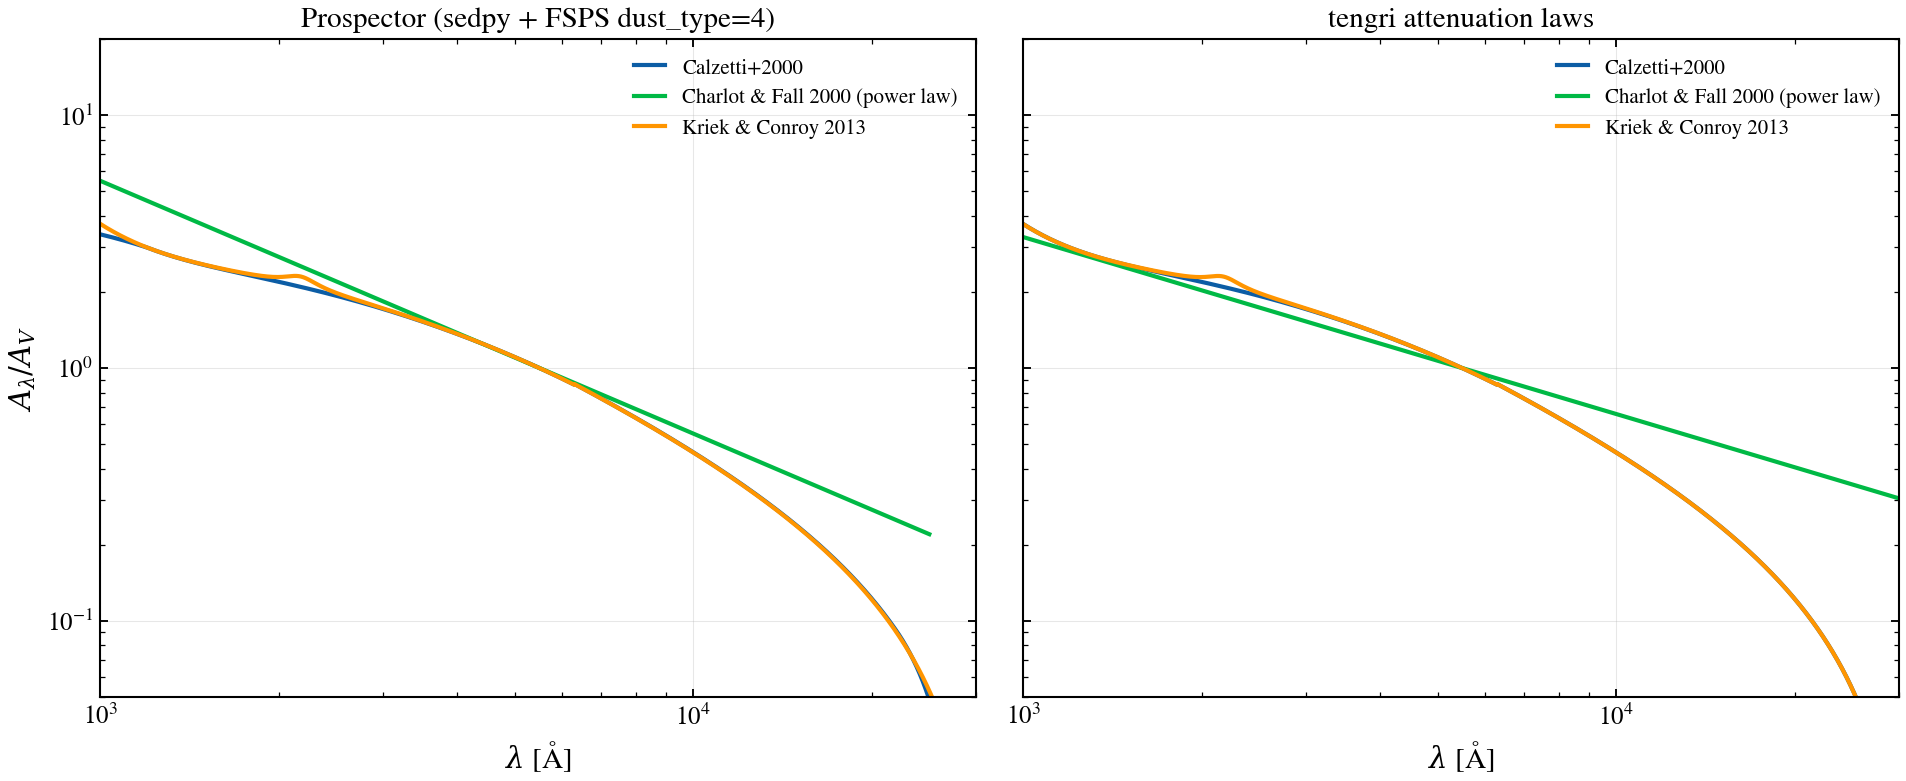

In [12]:
from tengri.dust import list_laws

# (sedpy name, tengri law name, label) for the three matched laws.
_law_pairs = [
    ("calzetti", "calzetti", "Calzetti+2000"),
    ("powerlaw", "power_law", "Charlot & Fall 2000 (power law)"),
    ("conroy", "kriek_conroy", "Kriek & Conroy 2013"),
]
_tengri_laws = list_laws(headline=False)  # {name: fn(wave_aa) -> k at tau_V=1}
wave_law = np.logspace(np.log10(1000.0), np.log10(30000.0), 2000)


def _norm_AV(wave, A):
    """A(λ) normalised to A_V at 5500 Å."""
    return A / A[np.argmin(np.abs(wave - 5500.0))]


def _bump_excess(wave, A_over_AV):
    """2175 Å bump height above the local Calzetti baseline, in A_λ/A_V."""
    i = np.argmin(np.abs(wave - 2175.0))
    lo = A_over_AV[np.argmin(np.abs(wave - 1950.0))]
    hi = A_over_AV[np.argmin(np.abs(wave - 2500.0))]
    return float(A_over_AV[i] - 0.5 * (lo + hi))


fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(13, 5.5), sharey=True)
for ax, title in (
    (ax_l, "Prospector (sedpy + FSPS dust_type=4)"),
    (ax_r, "tengri attenuation laws"),
):
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(r"$\lambda$ [Å]")
    ax.set_xlim(1e3, 3e4)
    ax.set_ylim(0.05, 20)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
ax_l.set_ylabel(r"$A_\lambda / A_V$")

for sedpy_name, tengri_law, label in _law_pairs:
    if tengri_law == "kriek_conroy":
        # Prospector applies KC13 through FSPS dust_type=4, not sedpy.conroy.
        A_p = P.fsps_kriek_conroy_curve(wave_law)
        w_p = wave_law
    else:
        w_p, A_p = P.attenuation_curve(sedpy_name, av=1.0)
    A_p_norm = _norm_AV(w_p, A_p)
    ax_l.plot(w_p, A_p_norm, linewidth=2.0, label=label)

    # tengri's law functions are JAX-native but accept array-likes; the
    # result is wrapped back to NumPy for plotting.
    A_t = np.asarray(_tengri_laws[tengri_law](wave_law))
    A_t_norm = _norm_AV(wave_law, A_t)
    ax_r.plot(wave_law, A_t_norm, linewidth=2.0, label=label)

    if tengri_law == "kriek_conroy":
        print(
            f"§4 Kriek & Conroy 2175 Å bump (A_λ/A_V above baseline): "
            f"FSPS dust_type=4 = {_bump_excess(w_p, A_p_norm):.3f}, "
            f"tengri = {_bump_excess(wave_law, A_t_norm):.3f}"
        )
ax_l.legend(fontsize=10)
ax_r.legend(fontsize=10)
fig.tight_layout()
save_fig("prospector_04_dust_attenuation.png")

## §5 Attenuation applied

The fiducial galaxy with and without dust. Prospector applies the
Calzetti law as a single screen at A_V = 1 (FSPS `dust_type=2`,
`dust2 = A_V/1.086`, `dust1 = 0` — no extra birth-cloud term). tengri
matches by putting the full A_V on the diffuse component, which
attenuates all ages equally, and zeroing the birth-cloud term — tengri's
`τ_bc` attenuates only stars younger than ~10 Myr. (An even split would
under-attenuate the old population that dominates the 5 Gyr fiducial,
leaving the optical ~1.5× too bright.)

W0619 14:04:59.054774 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:04:59.059904 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:04:59.064183 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


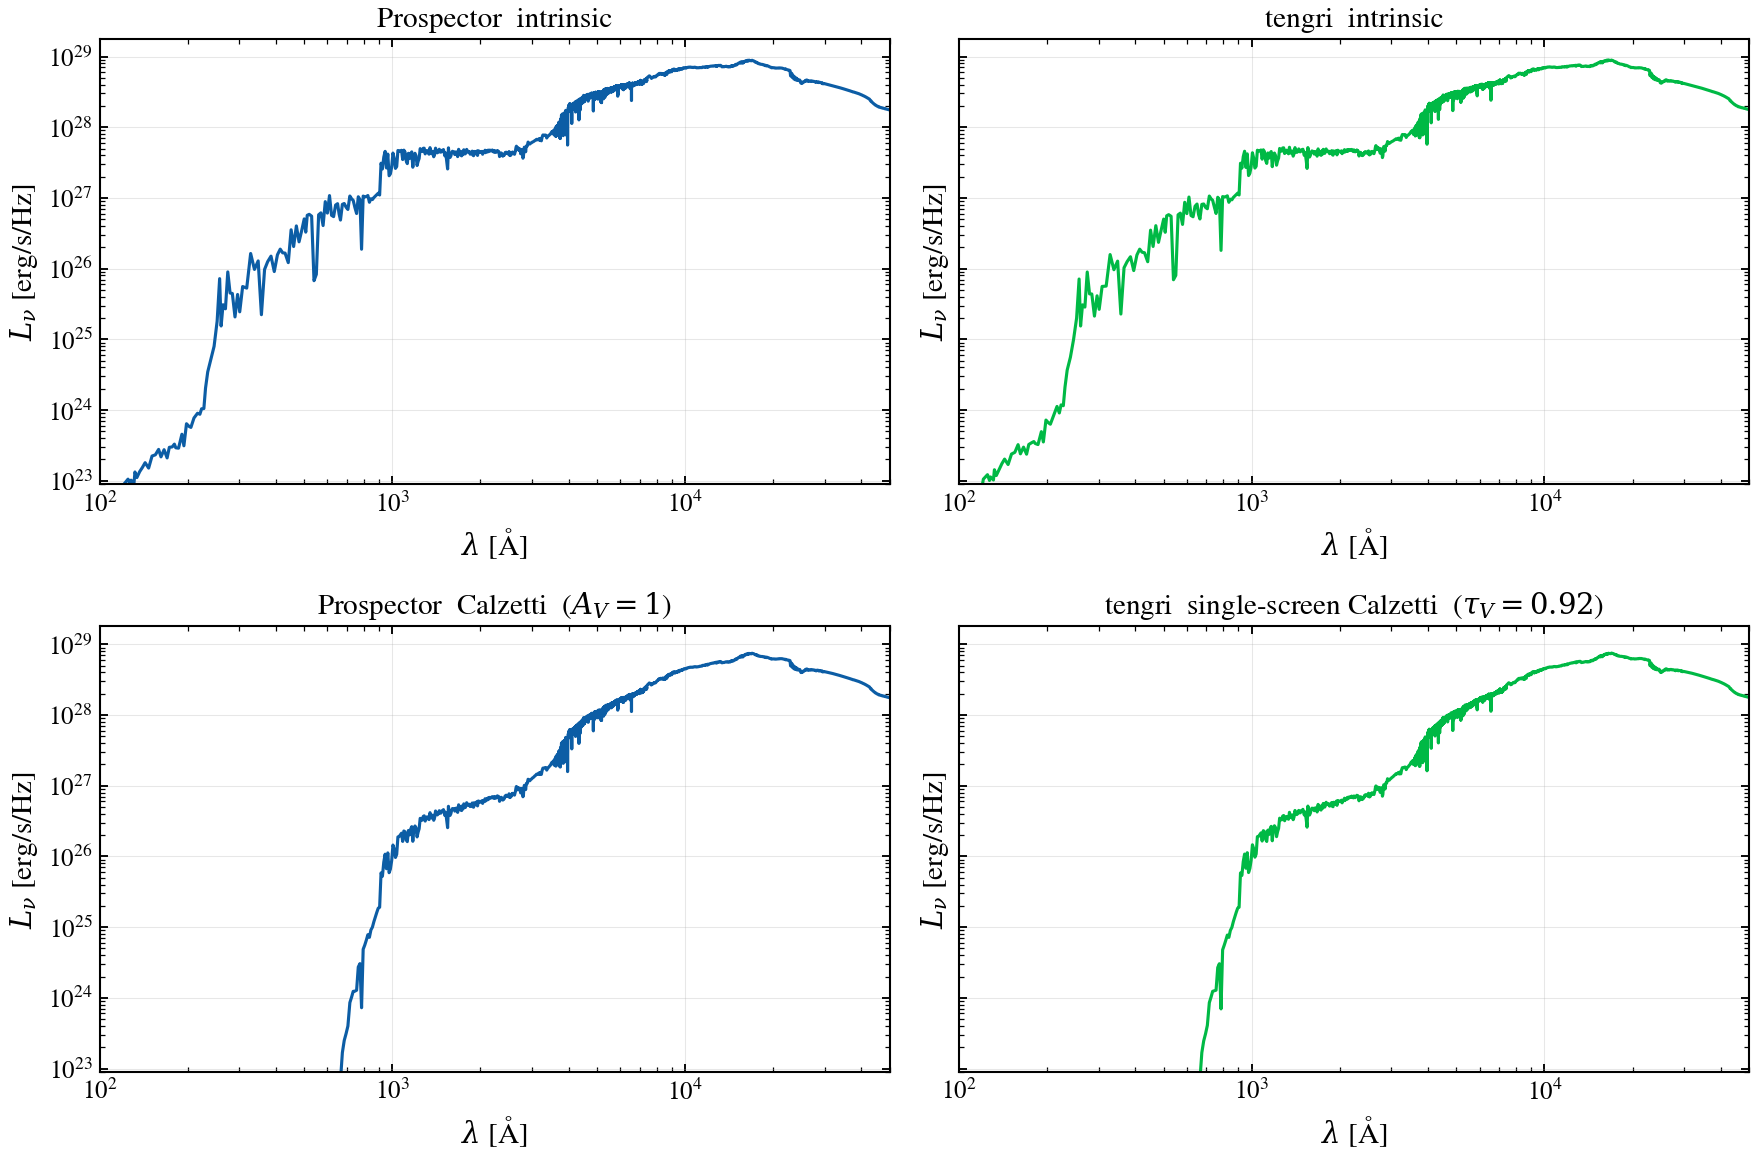

In [13]:
TAU_DIFF = AV_FIDUCIAL / 1.086  # full single screen on the diffuse (all-age) component
TAU_BC = 0.0  # birth-cloud term off — matches FSPS dust1 = 0

w_p_nd, L_p_nd = P.csp_lnu(tau=TAU_GYR_FIDUCIAL, tage=AGE_GYR_FIDUCIAL, av=0.0)
w_p_d, L_p_d = P.csp_lnu(tau=TAU_GYR_FIDUCIAL, tage=AGE_GYR_FIDUCIAL, av=AV_FIDUCIAL, dust_type=2)
L_p_nd = L_p_nd * MASS_SCALE
L_p_d = L_p_d * MASS_SCALE

s_nd = s_stellar  # intrinsic reuse from §3 (already at 10^10 M⊙)
m_d = SEDModel.build(
    ssp_data=ssp,
    stellar=STELLAR_FIDUCIAL,
    sfh={
        "type": "delayed",
        "tau_gyr": Fixed(TAU_GYR_FIDUCIAL),
        "age_gyr": Fixed(AGE_GYR_FIDUCIAL),
        "log_total_mass": Fixed(LOG_MASS_FIDUCIAL),
        "*": FIXED,
    },
    dust={
        "type": "two_component",
        "law_bc": "calzetti",
        "law_diff": "calzetti",
        "tau_bc": Fixed(TAU_BC),
        "tau_diff": Fixed(TAU_DIFF),
        "*": FIXED,
    },
    redshift=Fixed(0.0),
)
s_d = m_d.predict_state({})
_assert_comparable(L_p_d, s_d.derived["sed_dust_attenuated"], name="§5 dust applied")

fig, ((ax_l1, ax_r1), (ax_l2, ax_r2)) = plt.subplots(2, 2, sharey=True, figsize=(12, 8))
U.panel(ax_l1, ax_r1, label_l="Prospector  intrinsic", label_r="tengri  intrinsic")
U.panel(
    ax_l2,
    ax_r2,
    label_l=rf"Prospector  Calzetti  ($A_V = {AV_FIDUCIAL:g}$)",
    label_r=rf"tengri  single-screen Calzetti  ($\tau_V={TAU_DIFF:.2f}$)",
)
ax_l1.plot(w_p_nd, L_p_nd, "C0-", linewidth=1.5)
ax_r1.plot(s_nd.wave, s_nd.sed_intrinsic, "C1-", linewidth=1.5)
ax_l2.plot(w_p_d, L_p_d, "C0-", linewidth=1.5)
ax_r2.plot(s_d.wave, s_d.derived["sed_dust_attenuated"], "C1-", linewidth=1.5)
_ymax = float(np.asarray(s_nd.sed_intrinsic).max())
for ax in (ax_l1, ax_r1, ax_l2, ax_r2):
    ax.set_xlim(1e2, 5e4)
    ax.set_ylim(_ymax * 1e-6, _ymax * 2)
    ax.grid(True, alpha=0.3)
fig.tight_layout()
save_fig("prospector_05_dust_applied.png")

## §6 Dust IR re-emission and energy balance

Absorbed stellar UV/optical reappears in the infrared. Prospector
enables the Draine & Li (2007) templates with `add_dust_emission=True`,
parametrised by `(q_PAH, U_min, γ)` — the FSPS default dust emission.
tengri uses its own DL07 template grid and enforces energy balance,
`L_IR_emitted ≡ L_absorbed`, to floating point; the residual is
annotated on the right.

At matched `(q_PAH, U_min, γ)` the DL07 IR now agrees with FSPS in shape
(both peak near ~130 µm at `U_min = 1`; the 30–100 µm and submm bands
track to ~6 %), not just bolometrically. The DL07 power-law (PDR)
luminosity weighting is crucial: `γ` is a dust-*mass* fraction but the
PDR dust emits `R = U_max ln(U_max/U_min)/(U_max − U_min) ≈ 14×` more
per unit mass (DL07 Eq. 33). With this correction, the warm component
receives the correct weight and the IR shape matches FSPS and BAGPIPES
observations.

W0619 14:05:00.457247 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:05:00.473603 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:05:00.477810 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:05:00.481470 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:05:00.490775 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:05:00.496023 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:05:00.499640 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:05:00.510652 40419070 pjrt_executable.cc:638] 

W0619 14:05:00.681428 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:05:00.774143 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0619 14:05:01.034254 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:05:01.177539 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0619 14:05:01.497074 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0619 14:05:01.709110 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0619 14:05:02.058247 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


§6 tengri energy balance: L_abs = 2.221e+43, L_IR = 2.221e+43, resid = 0.00e+00


§6 FSPS far-IR peak at 142 µm


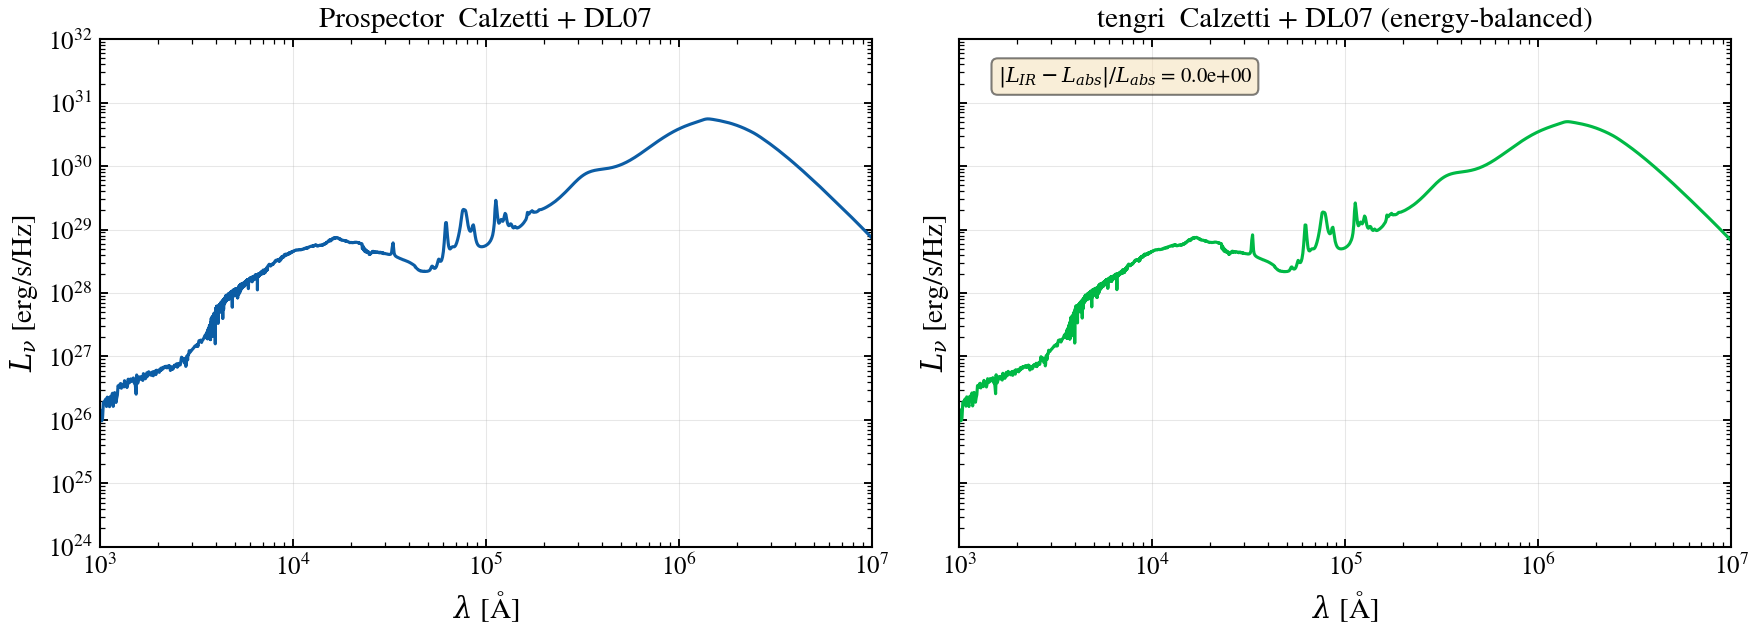

In [14]:
w_p_ir, L_p_ir = P.csp_lnu(
    tau=TAU_GYR_FIDUCIAL,
    tage=AGE_GYR_FIDUCIAL,
    av=AV_FIDUCIAL,
    dust_type=2,
    add_dust_emission=True,
    duste_qpah=QPAH_FIDUCIAL,
    duste_umin=UMIN_FIDUCIAL,
    duste_gamma=GAMMA_FIDUCIAL,
)
L_p_ir = L_p_ir * MASS_SCALE

m_ir = SEDModel.build(
    ssp_data=ssp,
    stellar=STELLAR_FIDUCIAL,
    sfh={
        "type": "delayed",
        "tau_gyr": Fixed(TAU_GYR_FIDUCIAL),
        "age_gyr": Fixed(AGE_GYR_FIDUCIAL),
        "log_total_mass": Fixed(LOG_MASS_FIDUCIAL),
        "*": FIXED,
    },
    dust={
        "type": "two_component",
        "law_bc": "calzetti",
        "law_diff": "calzetti",
        "tau_bc": Fixed(TAU_BC),
        "tau_diff": Fixed(TAU_DIFF),
        "emission": {
            "type": "draine_li2007",
            "qpah": Fixed(QPAH_FIDUCIAL),
            "umin": Fixed(UMIN_FIDUCIAL),
            "gamma_dl": Fixed(GAMMA_FIDUCIAL),
            "*": FIXED,
        },
        "*": FIXED,
    },
    redshift=Fixed(0.0),
)
s_ir = m_ir.predict_state({})
_L_abs = float(np.asarray(s_ir.derived["L_absorbed"]))
_L_ir = float(np.asarray(s_ir.derived["L_ir"]))
_eb_resid = abs(_L_ir - _L_abs) / max(_L_abs, 1e-30)
print(
    f"§6 tengri energy balance: L_abs = {_L_abs:.3e}, L_IR = {_L_ir:.3e}, resid = {_eb_resid:.2e}"
)

fig, ax_l, ax_r = U.two_panel_fig()
U.panel(
    ax_l,
    ax_r,
    label_l="Prospector  Calzetti + DL07",
    label_r="tengri  Calzetti + DL07 (energy-balanced)",
)
ax_l.plot(w_p_ir, L_p_ir, "C0-", linewidth=1.5)
sed_full_t = np.asarray(s_ir.derived["sed_dust_attenuated"]) + np.asarray(
    s_ir.derived["sed_dust_ir"]
)
ax_r.plot(s_ir.wave, sed_full_t, "C1-", linewidth=1.5)
ax_r.text(
    0.05,
    0.95,
    rf"$|L_{{IR}} - L_{{abs}}| / L_{{abs}}$ = {_eb_resid:.1e}",
    transform=ax_r.transAxes,
    fontsize=10,
    va="top",
    bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5),
)
for ax in (ax_l, ax_r):
    ax.set_xlim(1e3, 1e7)
    ax.set_ylim(1e24, 1e32)
    ax.grid(True, alpha=0.3)
fig.tight_layout()
save_fig("prospector_06_dust_ir.png")

# Far-IR peak location, a robust scalar diagnostic.
_p_fir = w_p_ir[(w_p_ir > 1e5) & (w_p_ir < 1e7)]
_L_fir = L_p_ir[(w_p_ir > 1e5) & (w_p_ir < 1e7)]
_peak_p = _p_fir[np.argmax(_L_fir)]
print(f"§6 FSPS far-IR peak at {_peak_p / 1e4:.0f} µm")

## §7 Panchromatic SED

Stellar + nebular + dust attenuation + DL07 IR, on one axis from the
rest-UV to the far-IR. The percent-level disagreements seen in §3–§6
(and the larger nebular gap of §8) stack here; the headline is the
overall shape, not bit-for-bit agreement at any one wavelength.

W0619 14:05:02.996829 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:05:03.000601 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:05:03.004405 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:05:03.007663 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:05:03.010518 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:05:03.013940 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:05:03.017043 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:05:03.038434 40419070 pjrt_executable.cc:638] 

W0619 14:05:03.204278 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:05:03.214780 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:05:03.219262 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:05:03.224302 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:05:03.268269 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:05:03.272475 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:05:03.276936 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:05:03.280434 40419070 pjrt_executable.cc:638] 

W0619 14:05:03.408782 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:05:03.413622 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:05:03.418278 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:05:03.423033 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:05:03.426899 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:05:03.430818 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:05:03.434600 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:05:03.445598 40419070 pjrt_executable.cc:638] 

W0619 14:05:03.654348 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:05:03.690920 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:05:03.775879 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0619 14:05:03.883117 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:05:03.897211 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:05:03.902892 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:05:03.906943 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:05:03.911275 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:05:03.915695 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:05:03.971299 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:05:03.976137 40419070 pjrt_executable.cc:638] 

...

W0619 14:05:05.342769 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:05:05.543517 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0619 14:05:05.548401 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:05:05.552524 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:05:05.555873 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:05:05.559572 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:05:05.563368 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:05:05.573341 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0619 14:05:05.867801 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:05:06.033596 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0619 14:05:06.086009 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:05:06.093112 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:05:06.122679 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0619 14:05:06.313330 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


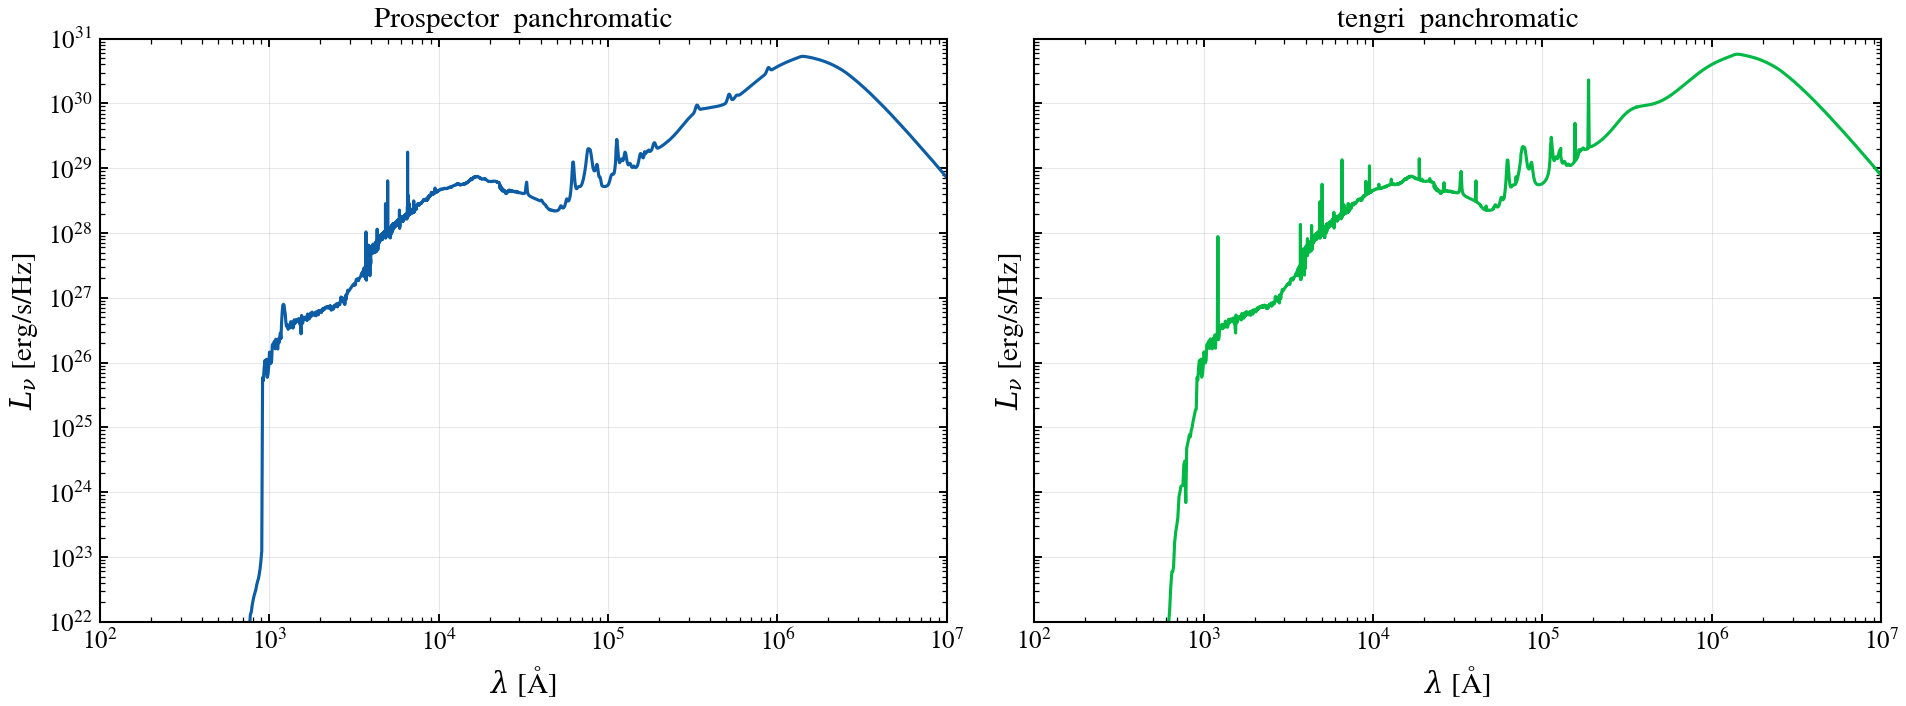

In [15]:
w_p_full, L_p_full = P.csp_lnu(
    tau=TAU_GYR_FIDUCIAL,
    tage=AGE_GYR_FIDUCIAL,
    av=AV_FIDUCIAL,
    dust_type=2,
    add_dust_emission=True,
    duste_qpah=QPAH_FIDUCIAL,
    duste_umin=UMIN_FIDUCIAL,
    duste_gamma=GAMMA_FIDUCIAL,
    add_neb_emission=True,
    gas_logu=-2.0,
    gas_logz=0.0,
)
L_p_full = L_p_full * MASS_SCALE

m_full = SEDModel.build(
    ssp_data=ssp,
    stellar=STELLAR_FIDUCIAL,
    sfh={
        "type": "delayed",
        "tau_gyr": Fixed(TAU_GYR_FIDUCIAL),
        "age_gyr": Fixed(AGE_GYR_FIDUCIAL),
        "log_total_mass": Fixed(LOG_MASS_FIDUCIAL),
        "*": FIXED,
    },
    dust={
        "type": "two_component",
        "law_bc": "calzetti",
        "law_diff": "calzetti",
        "tau_bc": Fixed(TAU_BC),
        "tau_diff": Fixed(TAU_DIFF),
        "emission": {
            "type": "draine_li2007",
            "qpah": Fixed(QPAH_FIDUCIAL),
            "umin": Fixed(UMIN_FIDUCIAL),
            "gamma_dl": Fixed(GAMMA_FIDUCIAL),
            "*": FIXED,
        },
        "*": FIXED,
    },
    neb={"type": "cue", "neb_logU": Fixed(-2.0), "neb_logZ_gas": Fixed(0.0), "*": FIXED},
    redshift=Fixed(0.0),
)
s_full = m_full.predict_state({})

fig, ax_l, ax_r = U.two_panel_fig(figsize=(13, 5))
U.panel(ax_l, ax_r, label_l="Prospector  panchromatic", label_r="tengri  panchromatic")
ax_l.plot(w_p_full, L_p_full, "C0-", linewidth=1.5)
_sed_full_t = (
    np.asarray(s_full.derived["sed_dust_attenuated"])
    + np.asarray(s_full.derived["sed_dust_ir"])
    + np.asarray(s_full.derived["sed_nebular"])
)
ax_r.plot(s_full.wave, _sed_full_t, "C1-", linewidth=1.5)
for ax in (ax_l, ax_r):
    ax.set_xlim(1e2, 1e7)
    ax.set_ylim(1e22, 1e31)
    ax.grid(True, alpha=0.3)
fig.tight_layout()
save_fig("prospector_07_panchromatic.png")

## §8 Nebular emission

FSPS' nebular grid is Byler+2017 — Cloudy photoionisation models baked
into the population synthesis, parametrised by `(gas_logu, gas_logz)`.
tengri's nebular emitter is Cue (Li et al. 2025), a neural emulator
trained on a different Cloudy version with a different ionising-spectrum
parametrisation. **They will not agree**, and the gap is the point: it
reflects the Cloudy version difference plus the different convolution
paths (Cue operates on bare-stellar SSPs; FSPS on the SFH-integrated
spectrum). The panel quantifies the gap rather than hiding it, using the
**integrated** line luminosity (continuum-subtracted, width-independent) —
not a single-bin peak ratio, which would measure line width and grid
resolution rather than physics.

W0619 14:05:07.641845 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:05:07.646722 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:05:07.651113 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:05:07.656526 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:05:07.661012 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:05:07.664972 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:05:07.668658 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:05:07.700343 40419070 pjrt_executable.cc:638] 

W0619 14:05:07.843449 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:05:07.851614 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:05:07.932423 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:05:07.982295 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:05:07.993621 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:05:07.997858 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:05:08.001814 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:05:08.006129 40419070 pjrt_executable.cc:638] 

W0619 14:05:08.044886 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:05:08.049406 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:05:08.079666 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:05:08.083849 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:05:08.089011 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:05:08.111258 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:05:08.116289 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:05:08.120274 40419070 pjrt_executable.cc:638] 

W0619 14:05:08.248557 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:05:08.253396 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:05:08.257479 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:05:08.260951 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:05:08.282789 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:05:08.286874 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:05:08.391300 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:05:08.420914 40419070 pjrt_executable.cc:638] 

§8 integrated line luminosity (tengri Cue / FSPS Byler+2017):
    Hα 6563 Å: FSPS 3.20e+43, tengri 2.83e+43 erg/s → 0.88×
    [O III] 5007 Å: FSPS 2.33e+43, tengri 1.89e+43 erg/s → 0.81×
    Hβ 4861 Å: FSPS 1.05e+43, tengri 9.96e+42 erg/s → 0.95×


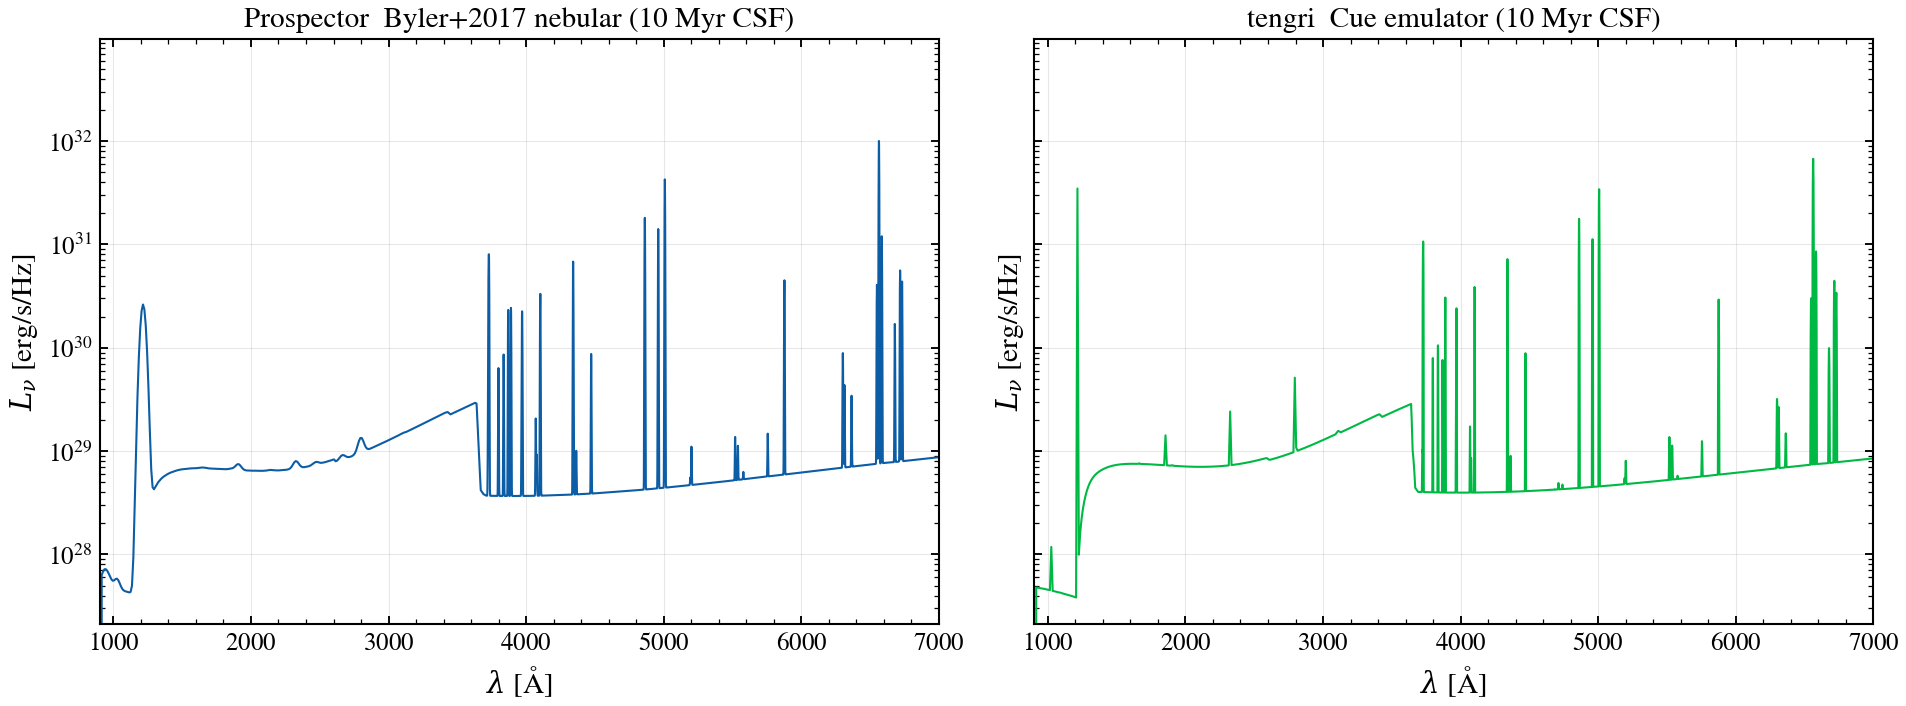

In [16]:
NEB_AGE = 0.01  # Gyr — a young constant-SFR population, where lines dominate

# FSPS nebular isolated as (neb on) − (neb off) at the same SFH.
w_p_neb, L_p_neb = P.isolate(
    dict(sfh=1, const=1.0, tage=NEB_AGE, add_neb_emission=True, gas_logu=-2.0, gas_logz=0.0),
    dict(sfh=1, const=1.0, tage=NEB_AGE),
)
L_p_neb = np.clip(L_p_neb, 0.0, None)

m_neb = SEDModel.build(
    ssp_data=ssp,
    stellar=STELLAR_FIDUCIAL,
    sfh={
        "type": "const",
        "start_gyr": Fixed(NEB_AGE),
        "end_gyr": Fixed(0.0),
        "log_total_mass": Fixed(9.0),
        "*": FIXED,
    },
    dust={"type": "two_component", "tau_bc": Fixed(0.0), "tau_diff": Fixed(0.0), "*": FIXED},
    neb={"type": "cue", "neb_logU": Fixed(-2.0), "neb_logZ_gas": Fixed(0.0), "*": FIXED},
    redshift=Fixed(0.0),
)
s_neb = m_neb.predict_state({})
L_t_neb = np.asarray(s_neb.derived["sed_nebular"])

# Rescale FSPS nebular to the same formed mass as the tengri build
# (tengri log_total_mass=9; FSPS curve is per 1 M⊙ formed).
L_p_neb_scaled = L_p_neb * 10.0**9.0

fig, ax_l, ax_r = U.two_panel_fig(figsize=(13, 5))
U.panel(
    ax_l,
    ax_r,
    label_l="Prospector  Byler+2017 nebular (10 Myr CSF)",
    label_r="tengri  Cue emulator (10 Myr CSF)",
)
ax_l.plot(w_p_neb, L_p_neb_scaled, "C0-", linewidth=1.0)
ax_r.plot(s_neb.wave, L_t_neb, "C1-", linewidth=1.0)
for ax in (ax_l, ax_r):
    ax.set_xlim(900, 7000)
    ax.set_xscale("linear")
    ax.grid(True, alpha=0.3)
# Integrated line luminosity (width- and grid-independent). A single-bin peak
# ratio measures line width, not luminosity — Cue broadens its lines while FSPS
# places them at the grid resolution, so a peak ratio is meaningless. Compare
# the brightest optical lines by their continuum-subtracted integrated flux.
_w_t = np.asarray(s_neb.wave)
print("§8 integrated line luminosity (tengri Cue / FSPS Byler+2017):")
for _c, _name in [(6563.0, "Hα"), (5007.0, "[O III]"), (4861.0, "Hβ")]:
    _lp = U.line_lum(w_p_neb, L_p_neb_scaled, _c)
    _lt = U.line_lum(_w_t, L_t_neb, _c)
    if _lp > 0:
        print(f"    {_name} {_c:.0f} Å: FSPS {_lp:.2e}, tengri {_lt:.2e} erg/s → {_lt / _lp:.2f}×")
fig.tight_layout()
save_fig("prospector_08_nebular.png")

## §9 AGN — Nenkova (2008) torus

Prospector's AGN component is the FSPS dust torus (Nenkova et al. 2008,
the CLUMPY models), switched on by `fagn > 0` and shaped by `agn_tau`.
It reprocesses a fraction `fagn` of the stellar bolometric luminosity
into mid-IR torus emission — there is no separate accretion-disc
continuum. tengri's `agn.torus = "nenkova"` is the matching block. We
read FSPS' actual torus luminosity from the difference (AGN on − AGN
off) and feed the same bolometric luminosity into tengri so the two
torus SEDs are normalised consistently.

tengri's `nenkova` block interpolates the *same* FSPS CLUMPY template
library (`Nenkova08_y010_torusg_n10_q2.0`) that Prospector uses, with a
differentiable triweight kernel in the equatorial optical depth `agn_tau`
— so the optical depth is a fitted parameter here exactly as in Prospector,
not a frozen template. At matched bolometric luminosity the two torus SEDs
trace the same templates: the mid-IR peak wavelength and the 10 µm silicate
feature coincide, and the remaining amplitude difference comes only from how
each code normalises the torus to the AGN bolometric luminosity.

§9 FSPS torus L_bol = 2.243e+43 erg/s = 10^9.77 L⊙


W0619 14:05:09.319883 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:05:09.325241 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:05:09.347752 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:05:09.354344 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:05:09.357830 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:05:09.361955 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:05:09.366052 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:05:09.408129 40419070 pjrt_executable.cc:638] 

W0619 14:05:09.543346 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:05:09.549486 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:05:09.553394 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:05:09.556899 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:05:09.560601 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:05:09.564855 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:05:09.568672 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:05:09.572001 40419070 pjrt_executable.cc:638] 

§9 torus mid-IR peak: FSPS 22.1 µm, tengri 22.1 µm


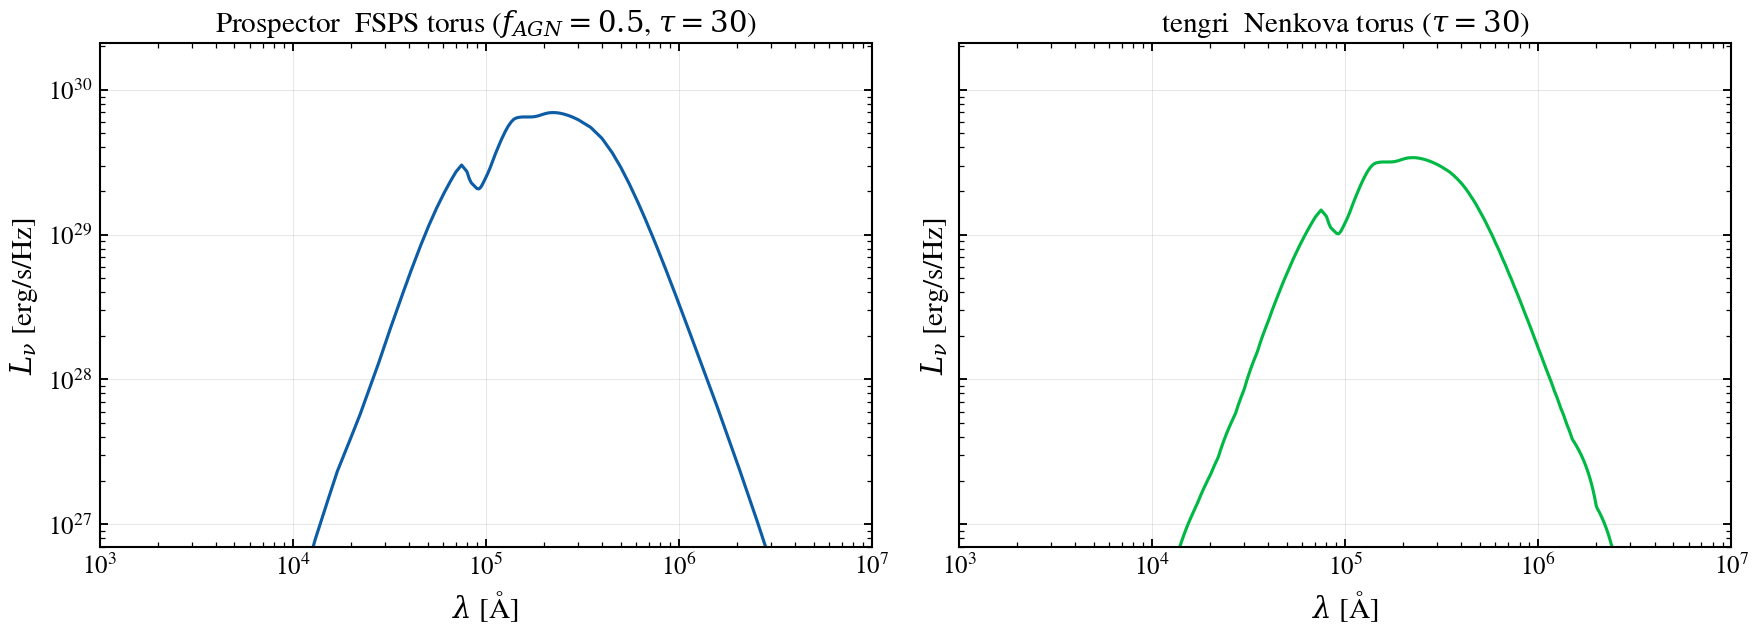

In [17]:
FAGN = 0.5
AGN_TAU = 30.0

# FSPS torus isolated as (fagn on) − (fagn off), and its bolometric.
w_p_agn, L_p_agn = P.isolate(
    dict(
        tau=TAU_GYR_FIDUCIAL, tage=AGE_GYR_FIDUCIAL, add_agn_dust=True, fagn=FAGN, agn_tau=AGN_TAU
    ),
    dict(tau=TAU_GYR_FIDUCIAL, tage=AGE_GYR_FIDUCIAL),
)
L_p_agn = np.clip(L_p_agn, 0.0, None)
# Bolometric of the FSPS torus per 1 M⊙ formed [erg/s], integrated over ν,
# then scaled to the 10^10 M⊙ galaxy. agn_log_lbol = log10(L_torus / L⊙).
_nu = U.C_ANGSTROM_PER_S / w_p_agn[::-1]
_L_agn_bol_erg = float(np.trapezoid(L_p_agn[::-1], _nu)) * MASS_SCALE
_L_agn_bol_lsun = _L_agn_bol_erg / U.L_SUN_ERG_PER_S
_agn_log_lbol = float(np.log10(_L_agn_bol_lsun))
L_p_agn = L_p_agn * MASS_SCALE  # plot the 10^10 M⊙ galaxy's torus
print(f"§9 FSPS torus L_bol = {_L_agn_bol_erg:.3e} erg/s = 10^{_agn_log_lbol:.2f} L⊙")

m_agn = SEDModel.build(
    ssp_data=ssp,
    stellar=STELLAR_FIDUCIAL,
    sfh={
        "type": "delayed",
        "tau_gyr": Fixed(TAU_GYR_FIDUCIAL),
        "age_gyr": Fixed(AGE_GYR_FIDUCIAL),
        "log_total_mass": Fixed(LOG_MASS_FIDUCIAL),
        "*": FIXED,
    },
    dust={"type": "two_component", "tau_bc": Fixed(0.0), "tau_diff": Fixed(0.0), "*": FIXED},
    agn={
        "type": "composable",
        "disc": {"type": "none"},
        "torus": {"type": "nenkova", "agn_tau": Fixed(AGN_TAU), "*": FIXED},
        "agn_log_lbol": Fixed(_agn_log_lbol),
        "*": FIXED,
    },
    redshift=Fixed(0.0),
)
s_agn = m_agn.predict_state({})
L_t_agn = np.asarray(s_agn.derived["sed_agn"])

fig, ax_l, ax_r = U.two_panel_fig()
U.panel(
    ax_l,
    ax_r,
    label_l=rf"Prospector  FSPS torus ($f_{{AGN}}={FAGN:g}$, $\tau={AGN_TAU:g}$)",
    label_r=rf"tengri  Nenkova torus ($\tau={AGN_TAU:g}$)",
)
ax_l.plot(w_p_agn, L_p_agn, "C0-", linewidth=1.5)
ax_r.plot(s_agn.wave, L_t_agn, "C1-", linewidth=1.5)
_peak_agn = max(float(np.max(L_p_agn)), float(np.max(L_t_agn)))
for ax in (ax_l, ax_r):
    ax.set_xlim(1e3, 1e7)
    ax.set_ylim(_peak_agn * 1e-3, _peak_agn * 3)
    ax.grid(True, alpha=0.3)
fig.tight_layout()
save_fig("prospector_09_agn_nenkova.png")

_peak_p_agn = w_p_agn[(w_p_agn > 1e4)][np.argmax(L_p_agn[(w_p_agn > 1e4)])]
_w_t_agn = np.asarray(s_agn.wave)
_peak_t_agn = _w_t_agn[(_w_t_agn > 1e4)][np.argmax(L_t_agn[(_w_t_agn > 1e4)])]
print(f"§9 torus mid-IR peak: FSPS {_peak_p_agn / 1e4:.1f} µm, tengri {_peak_t_agn / 1e4:.1f} µm")

## §12 IGM transmission — Madau (1995)

FSPS applies the Madau (1995) prescription for intergalactic Lyman-line
and Lyman-continuum absorption (`add_igm_absorption=True`). tengri ships
the same Madau form alongside its Inoue+2014 default. At the same
redshift the two should track closely; any residual is the difference
between the two implementations of the Madau coefficients, reported
below. (The IGM section numbering follows the CIGALE master sequence,
where §10 X-ray and §11 radio fall between — both absent from
Prospector.)

W0619 14:05:10.365575 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:05:10.370500 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:05:10.381009 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:05:10.386319 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0619 14:05:10.408900 40419070 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


§12 Madau IGM at z=4 (950–1216 Å): max |Δ| = 1.118e-02, median |Δ| = 1.035e-02


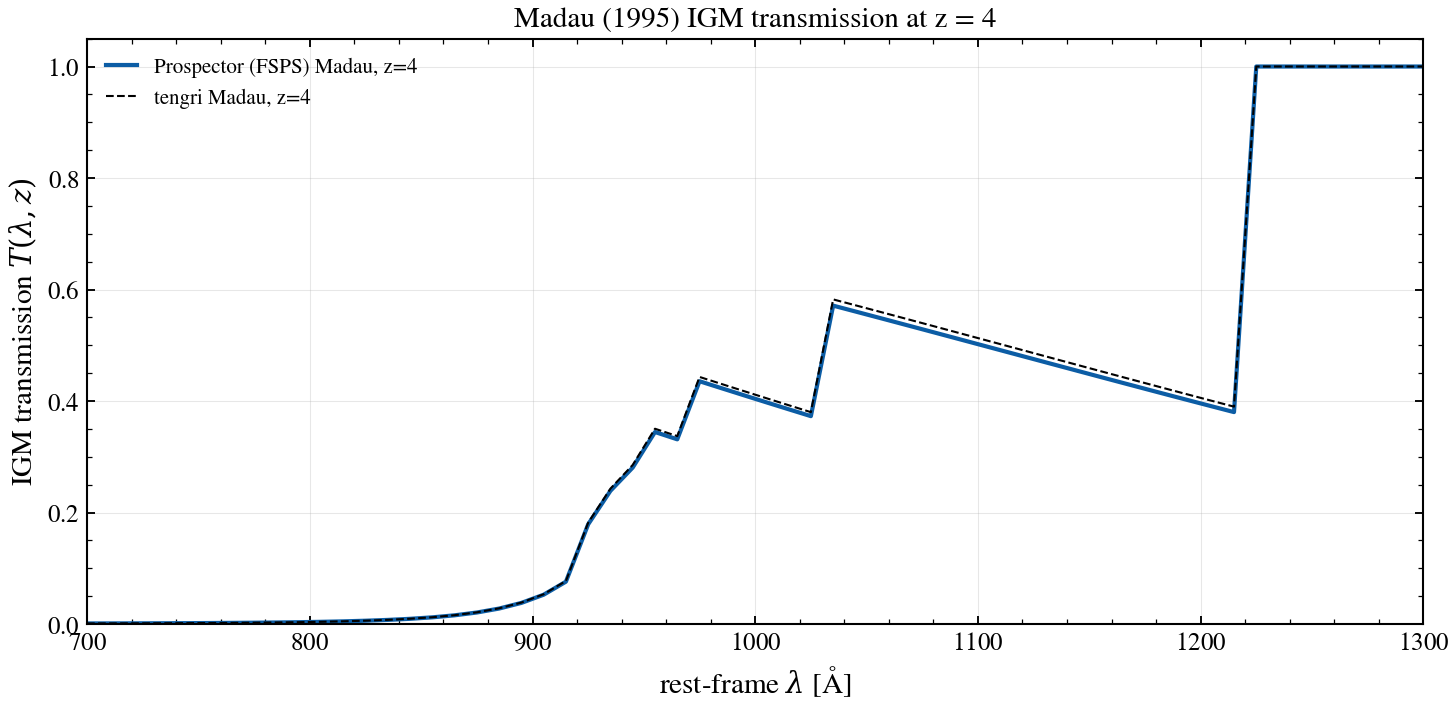

In [18]:
from tengri.components.igm.igm import igm_transmission_madau

Z_IGM = 4.0
w_p_igm, T_p_igm = P.igm_transmission(zred=Z_IGM, age_gyr=0.05)

# tengri's Madau is parametrised on observed-frame wavelengths.
wave_obs = w_p_igm * (1.0 + Z_IGM)
T_t_igm = np.asarray(igm_transmission_madau(wave_obs, np.asarray(Z_IGM)))

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(w_p_igm, T_p_igm, "C0-", linewidth=2.0, label=f"Prospector (FSPS) Madau, z={Z_IGM:g}")
ax.plot(w_p_igm, T_t_igm, "k--", linewidth=1.0, label=f"tengri Madau, z={Z_IGM:g}")
ax.set_xlabel(r"rest-frame $\lambda$ [Å]")
ax.set_ylabel(r"IGM transmission $T(\lambda, z)$")
ax.set_xlim(700, 1300)
ax.set_ylim(0, 1.05)
ax.set_title(f"Madau (1995) IGM transmission at z = {Z_IGM:g}")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
fig.tight_layout()
save_fig("prospector_12_igm_madau.png")

# Quantify agreement over the Lyman-α forest window.
_win = (w_p_igm >= 950) & (w_p_igm <= 1216)
_igm_diff = np.abs(T_t_igm[_win] - T_p_igm[_win])
print(
    f"§12 Madau IGM at z={Z_IGM:g} (950–1216 Å): "
    f"max |Δ| = {_igm_diff.max():.3e}, median |Δ| = {np.median(_igm_diff):.3e}"
)

## tengri in Prospector-mode — full-SED head-to-head

Every section above swept one physics block. This is the whole forward
model at once: tengri configured to emulate Prospector end to end — the
shared FSPS MIST+MILES SSP, the fiducial τ-delayed SFH, a Calzetti
attenuation law, Draine & Li (2007) IR re-emission, and nebular —
overlaid on FSPS's own panchromatic output at matched parameters (the §7
configuration). The top panel is the overlay; the bottom is the
fractional residual `tengri / FSPS − 1` with the ±25 % band shaded.
Optical agreement is reported as a normalization ratio and its 16–84 %
spread; with the dust applied as a single screen (§5) the whole optical
lands at ≈ 1.0× with a percent-level spread.

full-SED head-to-head tengri/FSPS optical (1000–10000 Å): normalization 1.01×, 16–84% spread 1.01–1.01×


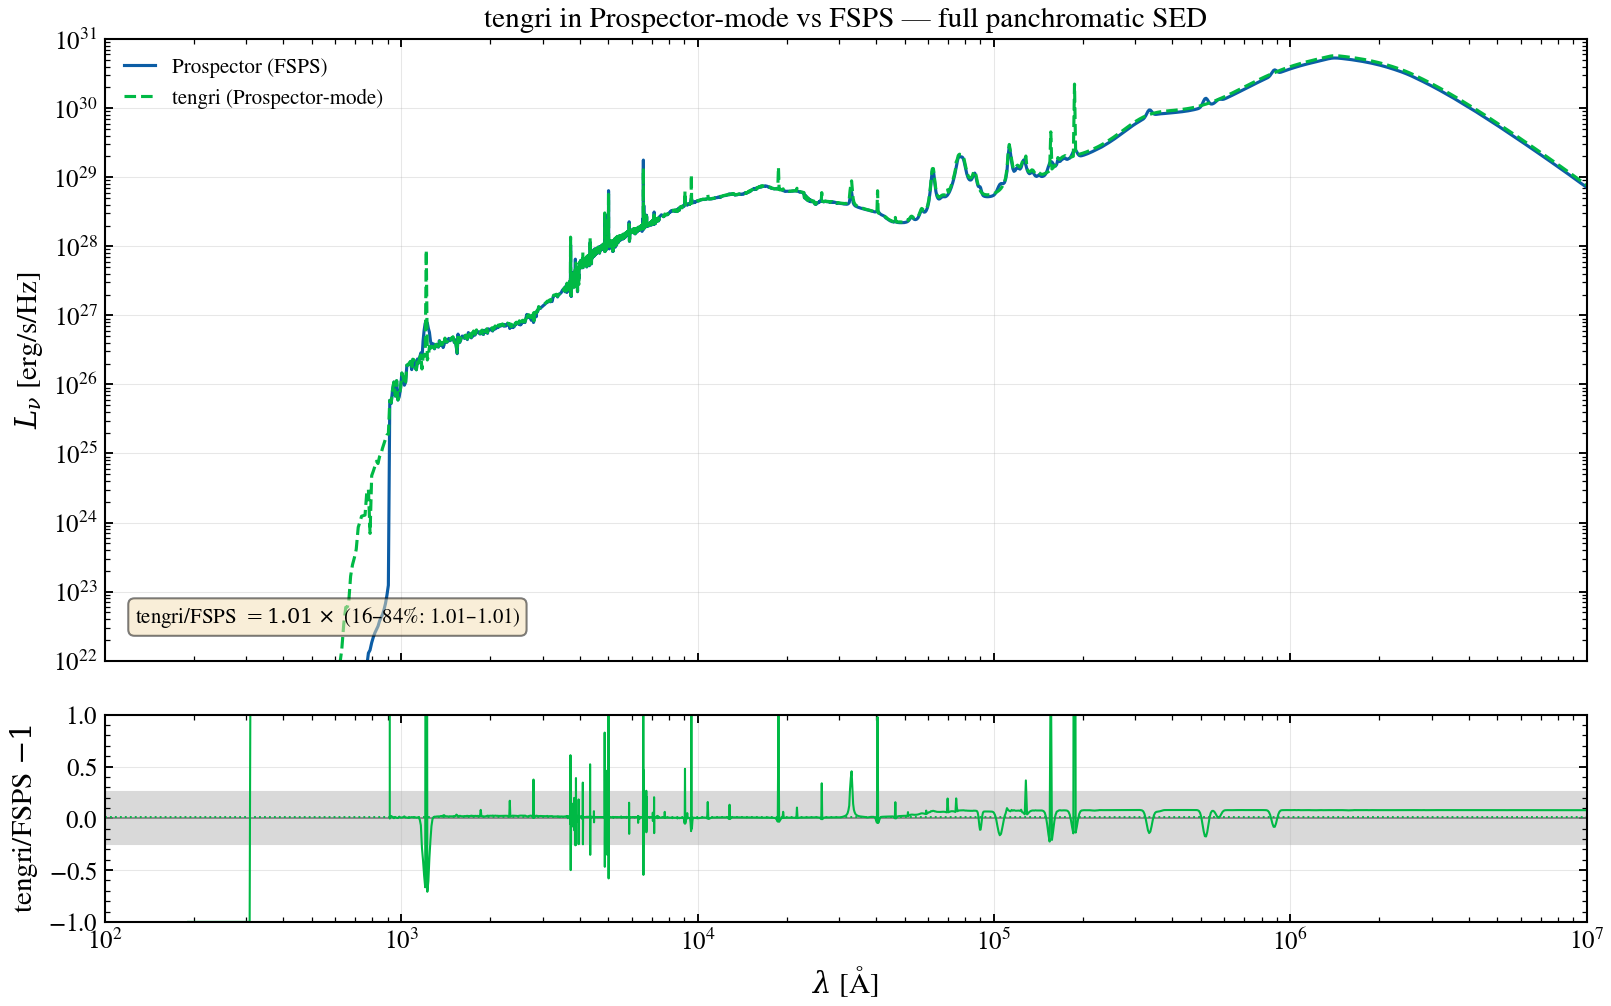

In [19]:
import chex

# Reuse the §7 panchromatic full SED: tengri's Prospector-mode model and
# FSPS's own output, both at the fiducial galaxy.
w_ext, L_ext = np.asarray(w_p_full), np.asarray(L_p_full)
wave_t = np.asarray(s_full.wave)
L_t = (
    np.asarray(s_full.derived["sed_dust_attenuated"])
    + np.asarray(s_full.derived["sed_dust_ir"])
    + np.asarray(s_full.derived["sed_nebular"])
)

# Put tengri on FSPS's wavelength grid so the two compare point for point.
L_t_on_ext = U.regrid(wave_t, L_t, w_ext)
chex.assert_equal_shape([L_ext, L_t_on_ext])

mask = (w_ext > 0) & (L_ext > 0) & (L_t_on_ext > 0)
resid = np.full(w_ext.shape, np.nan, dtype=float)
resid[mask] = L_t_on_ext[mask] / L_ext[mask] - 1.0

# Headline numbers: the optical normalization ratio tengri/FSPS and its
# 16–84% spread. With the §5 dust applied as a single screen matching
# FSPS `dust_type=2` (`dust1 = 0`), the whole optical lands at ≈ 1.0× with
# a tight spread — FSPS and tengri agree to a couple of percent across
# the band, lines included. Reporting the ratio + spread makes that match
# explicit.
opt = mask & (w_ext >= 1000.0) & (w_ext <= 10000.0)
ratio_opt = L_t_on_ext[opt] / L_ext[opt]
norm = float(np.median(ratio_opt))
p16, p84 = float(np.percentile(ratio_opt, 16)), float(np.percentile(ratio_opt, 84))
print(
    f"full-SED head-to-head tengri/FSPS optical (1000–10000 Å): "
    f"normalization {norm:.2f}×, 16–84% spread {p16:.2f}–{p84:.2f}×"
)
_assert_comparable(L_ext, L_t, name="full-SED head-to-head")

fig, (ax, ax_r) = plt.subplots(
    2, 1, figsize=(11, 7), sharex=True, gridspec_kw={"height_ratios": [3, 1]}
)
ax.plot(w_ext, L_ext, "C0-", linewidth=1.5, label="Prospector (FSPS)")
ax.plot(w_ext, L_t_on_ext, "C1--", linewidth=1.5, label="tengri (Prospector-mode)")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(1e2, 1e7)
ax.set_ylim(1e22, 1e31)
ax.set_ylabel(r"$L_\nu$ [erg/s/Hz]")
ax.set_title("tengri in Prospector-mode vs FSPS — full panchromatic SED")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.text(
    0.02,
    0.05,
    rf"tengri/FSPS $= {norm:.2f}\times$ (16–84%: {p16:.2f}–{p84:.2f})",
    transform=ax.transAxes,
    fontsize=10,
    va="bottom",
    bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5),
)

ax_r.axhspan(-0.25, 0.25, color="0.85", zorder=0)
ax_r.axhline(0.0, color="0.5", linewidth=0.8)
ax_r.axhline(norm - 1.0, color="C1", linestyle=":", linewidth=0.9)
ax_r.plot(w_ext, resid, "C1-", linewidth=1.0)
ax_r.set_xscale("log")
ax_r.set_xlim(1e2, 1e7)
ax_r.set_ylim(-1.0, 1.0)
ax_r.set_xlabel(r"$\lambda$ [Å]")
ax_r.set_ylabel(r"tengri/FSPS $-1$")
ax_r.grid(True, alpha=0.3)
fig.tight_layout()
save_fig("prospector_full_sed_headtohead.png")
plt.show()

## Summary

Component by component, at matched parameters, FSPS-via-Prospector and
tengri agree wherever they evaluate the same mathematics — the SSP
grid, the SFH shape, the attenuation curves (with the §5 single-screen
mapping), the DL07 dust IR (shape and energy balance with proper PDR
luminosity weighting), and the Madau IGM. The remaining difference is
the one place they use different physics inputs: the nebular grid (Cue
vs Byler+2017, §8). The full-SED head-to-head collects the whole
Prospector-mode forward model onto one axis with a fractional-residual
panel and an optical normalization ratio with its 16–84 % spread. The
per-section scalars printed above (residuals, ratios, peak locations)
are the quantitative record; the figures in `_figs/` are the visual one.

## References

* Johnson, Leja, Conroy & Speagle 2021, ApJS 254, 22 — Prospector
* Leja et al. 2017, ApJ 837, 170 — Dirichlet non-parametric SFH
* Leja et al. 2019, ApJ 876, 3 — continuity & continuity-flex SFH priors
* Suess et al. 2022, ApJ 935, 146 — post-starburst non-parametric SFH
* Conroy, Gunn & White 2009, ApJ 699, 486 — FSPS
* Conroy & Gunn 2010, ApJ 712, 833 — FSPS calibration
* Choi et al. 2016, ApJ 823, 102 — MIST isochrones
* Sánchez-Blázquez et al. 2006, MNRAS 371, 703 — MILES library
* Chabrier 2003, PASP 115, 763 — IMF
* Calzetti et al. 2000, ApJ 533, 682 — starburst attenuation
* Charlot & Fall 2000, ApJ 539, 718 — two-component dust
* Kriek & Conroy 2013, ApJL 775, L16 — modified attenuation
* Draine & Li 2007, ApJ 657, 810 — dust IR emission
* Byler et al. 2017, ApJ 840, 44 — nebular grid
* Nenkova et al. 2008, ApJ 685, 160 — clumpy torus
* Madau 1995, ApJ 441, 18 — IGM absorption
* Li et al. 2025 — Cue nebular emulator